---
# <div align="center"><font color='green'> COSC 2753 Machine Learning - Assignment 1  </font></div>
## <div align="center"> <font color='green'> Student name: Cao Nguyen Hai Linh</font></div>
## <div align="center"> <font color='green'> Student ID: s397838</font></div>
---

# **Introduction**

This notebook contains technical implementation following the course COSC2753 - Machine Learning Assignment 1 requirements. The principal objective is to explore different machine learning techniques, particularly regression, to address a practical issue. The dataset used for this assignment contains the target variable - life expectancy in years across various countries - along with other features representing a variety of life domains including health, disease immunization, economy, and demography.   


# **Data preprocessing**
## **Install neccessary libraries**

In [1]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import seaborn as sns
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import RobustScaler, QuantileTransformer, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, RidgeCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor, VotingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, PredictionErrorDisplay, r2_score
from sklearn.base import clone
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb

## **Data overview**

This dataset contains life expectancy (target variable), health, disease immunization, and economic and demographic information about 135 countries throughout the period of 2002 - 2017 years. The original dataset has 23 variables with all of them being numerical, excluding "ID", and 2071 entries.

In [89]:
train = pd.read_csv("train.csv")
test = pd.read_csv('test.csv')

In [83]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2071 entries, 0 to 2070
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            2071 non-null   int64  
 1   TARGET_LifeExpectancy         2071 non-null   float64
 2   Country                       2071 non-null   int64  
 3   Year                          2071 non-null   int64  
 4   Status                        2071 non-null   int64  
 5   AdultMortality                2070 non-null   float64
 6   AdultMortality-Male           2071 non-null   int64  
 7   AdultMortality-Female         2071 non-null   int64  
 8   SLS                           2071 non-null   int64  
 9   Alcohol                       2067 non-null   float64
 10  PercentageExpenditure         2062 non-null   float64
 11  Measles                       2070 non-null   float64
 12  BMI                           2063 non-null   float64
 13  Und

In [84]:
pd.set_option('display.max_columns', None)
train.describe()

,ID,TARGET_LifeExpectancy,Country,Year,Status,AdultMortality,AdultMortality-Male,AdultMortality-Female,SLS,Alcohol,PercentageExpenditure,Measles,BMI,Under5LS,Polio,TotalExpenditure,Diphtheria,HIV-AIDS,GDP,Population,Thinness1-19years,Thinness5-9years,IncomeCompositionOfResources,Schooling
count,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,2070.00000,2071.000000,2071.000000,2071.000000,2067.000000,2062.000000,2070.000000,2063.000000,2070.000000,2070.000000,2061.000000,2071.000000,2068.000000,2062.000000,2.063000e+03,2070.000000,2070.000000,2066.000000,2064.000000
mean,1036.000000,69.274505,95.360212,2009.518590,0.185418,162.82029,161.908257,163.759536,33.079672,4.693009,764.429066,2096.541063,37.572952,45.849275,82.720773,5.881827,82.753259,1.632544,7304.336600,1.205231e+07,4.939034,4.977971,0.609866,3.372332
std,597.990524,9.482281,54.861641,4.614147,0.388730,118.89928,119.442235,118.800292,135.832868,4.205270,2083.501026,9961.872486,19.946367,185.292194,23.192604,2.557347,23.130969,4.784991,15179.036764,6.403752e+07,4.697848,4.786593,0.216610,0.590975
min,1.000000,37.300000,0.000000,2002.000000,0.000000,1.00000,0.000000,2.000000,0.000000,0.010000,0.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.880000,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,518.500000,63.000000,50.000000,2006.000000,0.000000,74.00000,74.000000,74.000000,0.000000,0.615000,5.688828,0.000000,18.800000,0.000000,77.000000,4.180000,78.000000,0.100000,413.730000,1.274450e+05,1.600000,1.500000,0.463000,3.065942
50%,1036.000000,71.200000,94.000000,2010.000000,0.000000,144.00000,142.000000,144.000000,3.000000,3.820000,68.943329,19.000000,42.100000,4.000000,93.000000,5.640000,93.000000,0.100000,1390.315000,6.477440e+05,3.200000,3.300000,0.655500,3.449638
75%,1553.500000,76.000000,144.000000,2014.000000,0.000000,228.00000,228.000000,230.000000,22.000000,7.840000,429.434148,425.750000,55.900000,27.000000,97.000000,7.430000,97.000000,0.800000,5746.287500,5.364814e+06,7.375000,7.400000,0.770000,3.741657
max,2071.000000,92.700000,192.000000,2017.000000,1.000000,699.00000,704.000000,722.000000,1800.000000,17.870000,19479.911610,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,133473.470000,1.293859e+09,27.700000,28.600000,0.948000,4.381780


## **Handle missing value**

The original dataset contains a small proportion of missing values, in which none of them is contextual data, like “Year”. Therefore, instead of removing these entries - which could result in the loss of valuable information - a more appropriate approach is to apply imputation. The chosen method is K-Nearest Neighbors (KNN) imputer, which estimates missing values based on neighboring data points. Given the low percentage of missing data, this method is expected to have minimal impact on overall model performance. Furthermore, due to the presence of temporal variable, KNN algorithm will help preserve the chronological nature of data.

In [85]:
missing_percent = (train.isnull().sum() / len(train)) * 100
missing_percent = missing_percent[missing_percent > 0]
missing_percent

AdultMortality                  0.048286
Alcohol                         0.193143
PercentageExpenditure           0.434573
Measles                         0.048286
BMI                             0.386287
Under5LS                        0.048286
Polio                           0.048286
TotalExpenditure                0.482859
HIV-AIDS                        0.144858
GDP                             0.434573
Population                      0.386287
Thinness1-19years               0.048286
Thinness5-9years                0.048286
IncomeCompositionOfResources    0.241429
Schooling                       0.338001
dtype: float64

In [90]:
#Impute missing values with KNN imputer
imputer = KNNImputer(n_neighbors=5,weights="distance").set_output(transform='pandas')
train = imputer.fit_transform(train)

## **Exploratory Data Analysis**
### Univariate analysis

In [87]:
#Function to create histogram plot and box plot for univariate analysis
def plot_univariate(data, column, bins=30):
    """
    Plots a histogram with KDE and a boxplot for univariate analysis of a numerical column.
    
    Parameters:
        data (DataFrame): Pandas DataFrame containing the data.
        column (str): Column name to analyze.
        bins (int): Number of bins for the histogram. Default is 30.
    """
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})
    
    # Histogram with KDE
    sns.histplot(data[column], bins=bins, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram & KDE of {column}')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')
    
    # Boxplot
    sns.boxplot(x=data[column], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot of {column}')
    
    plt.tight_layout()
    plt.show()

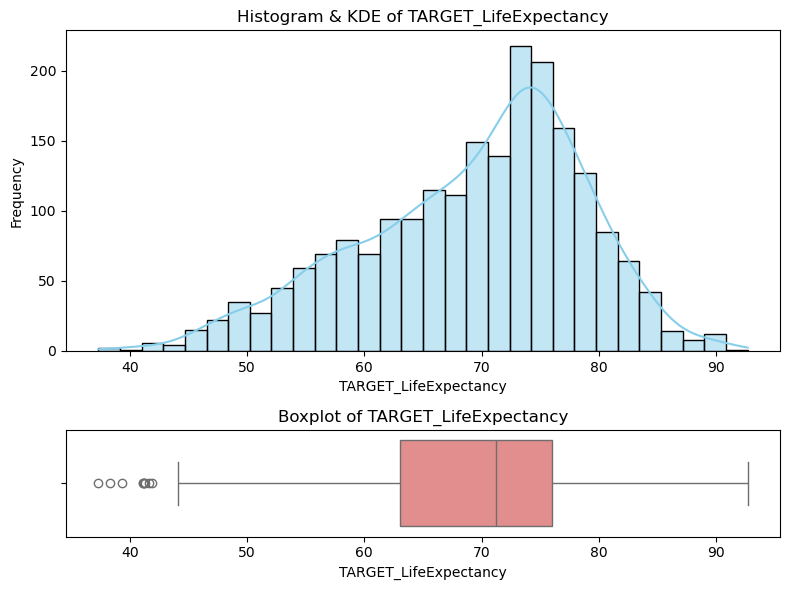

In [92]:
plot_univariate(train, 'TARGET_LifeExpectancy')

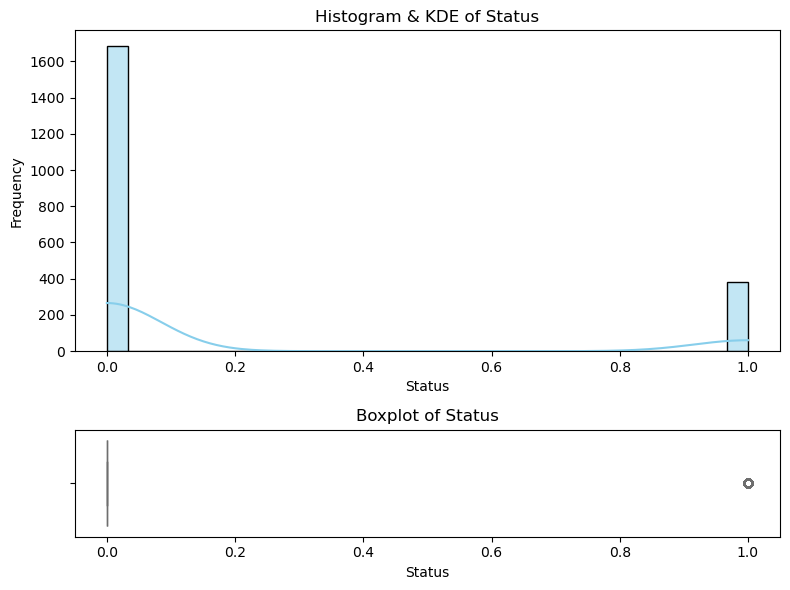

In [8]:
plot_univariate(train, 'Status')

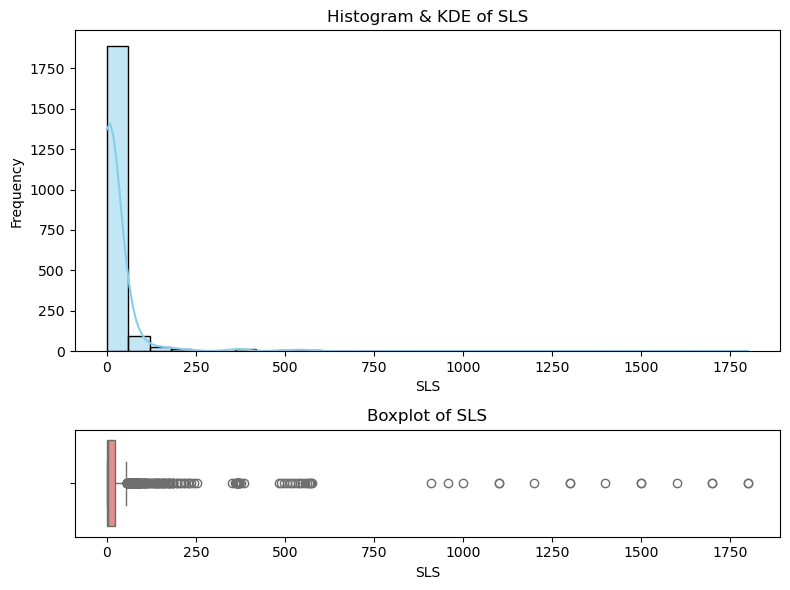

In [9]:
plot_univariate(train, 'SLS')

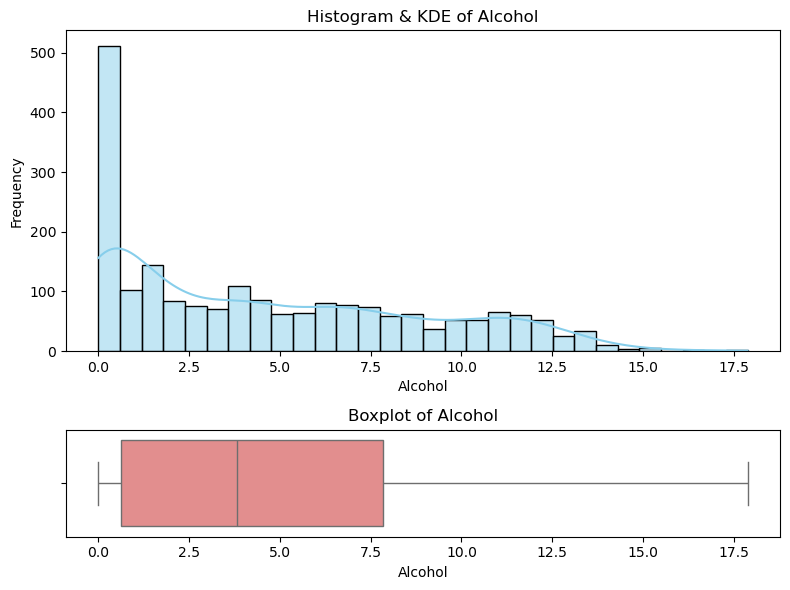

In [10]:
plot_univariate(train, 'Alcohol')

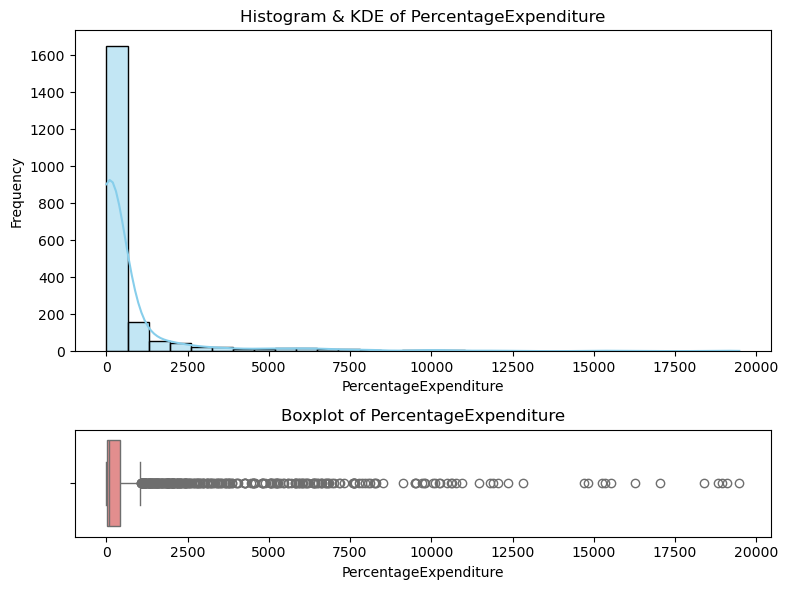

In [11]:
plot_univariate(train, 'PercentageExpenditure')

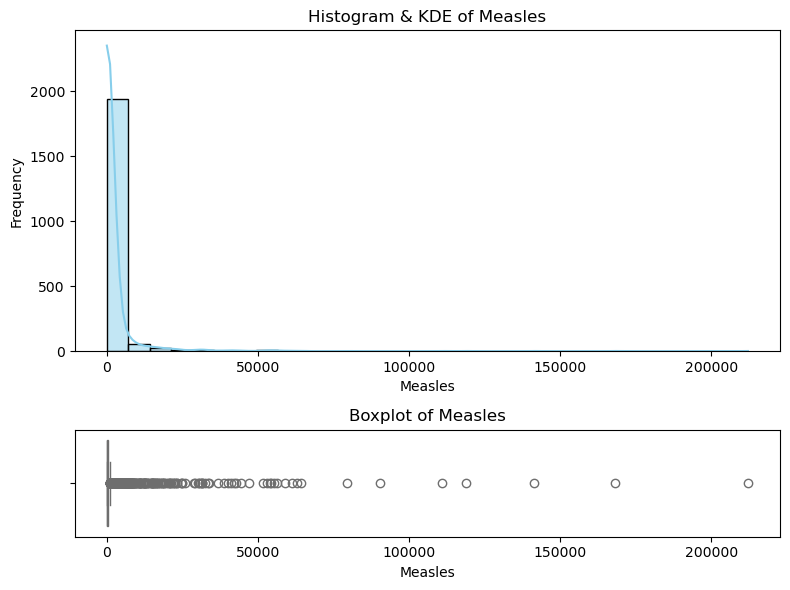

In [12]:
plot_univariate(train, 'Measles')

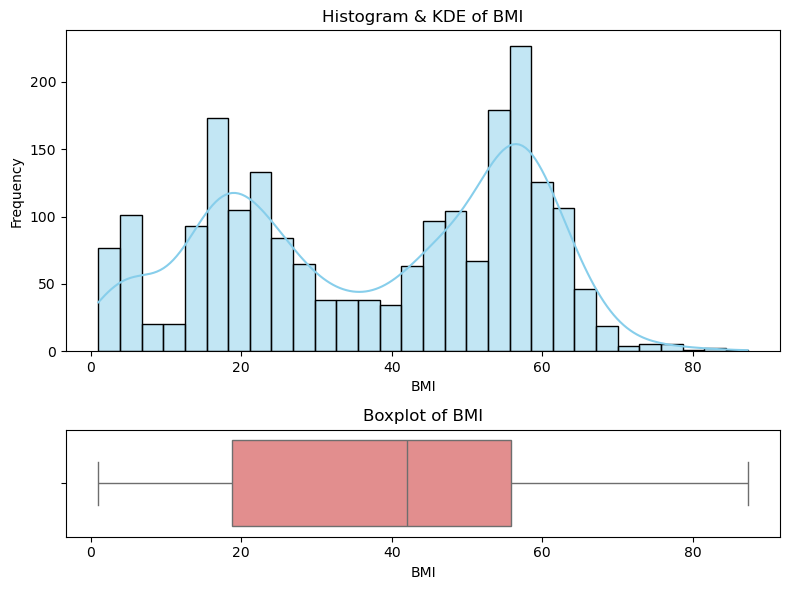

In [13]:
plot_univariate(train, 'BMI')

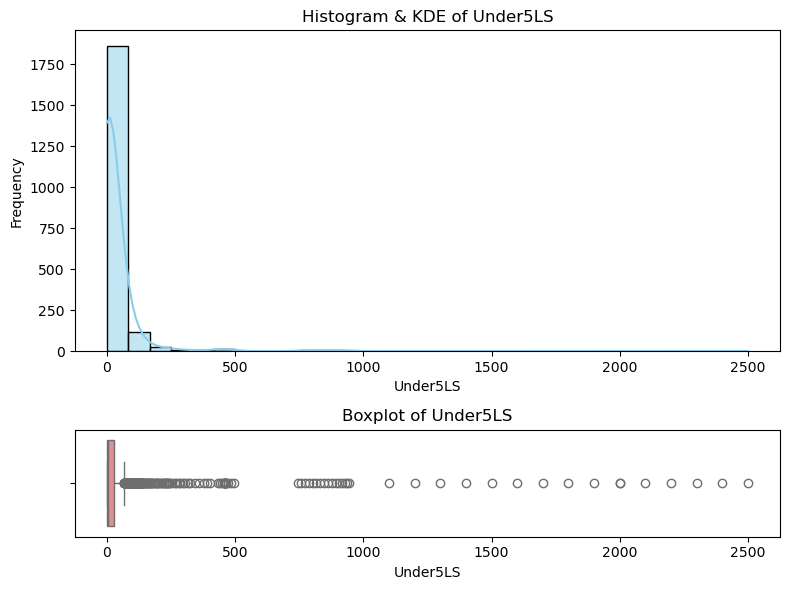

In [14]:
plot_univariate(train, 'Under5LS')

Remove all records with Under5LS value over 1000 (outlier)

In [15]:
train = train[train['Under5LS'] < 1000]

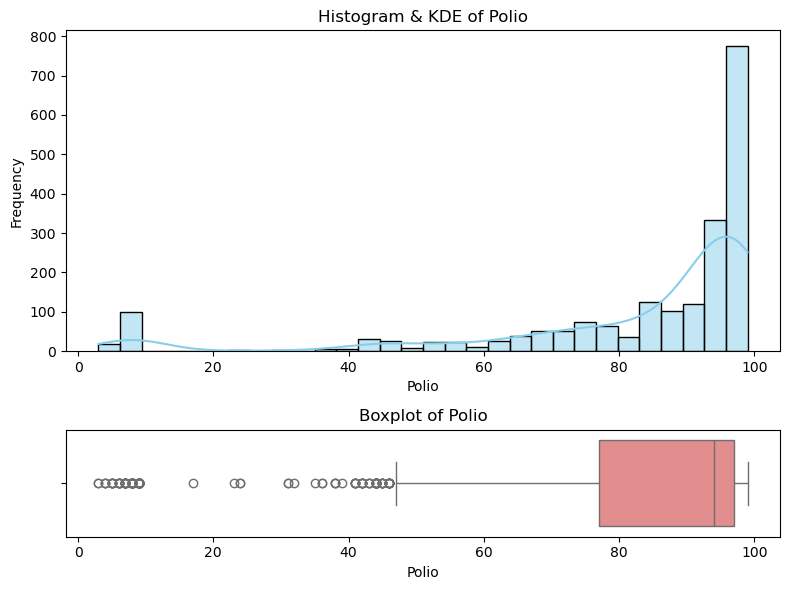

In [16]:
plot_univariate(train, 'Polio')

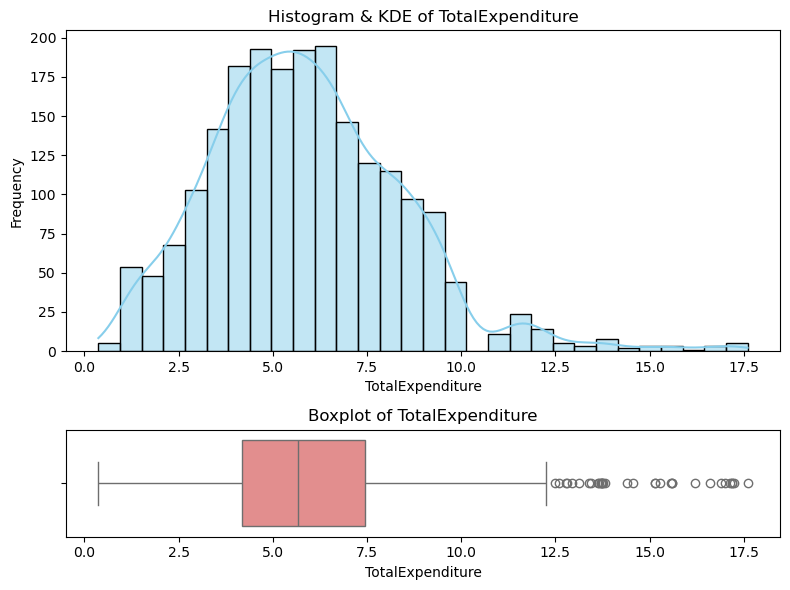

In [17]:
plot_univariate(train, 'TotalExpenditure')

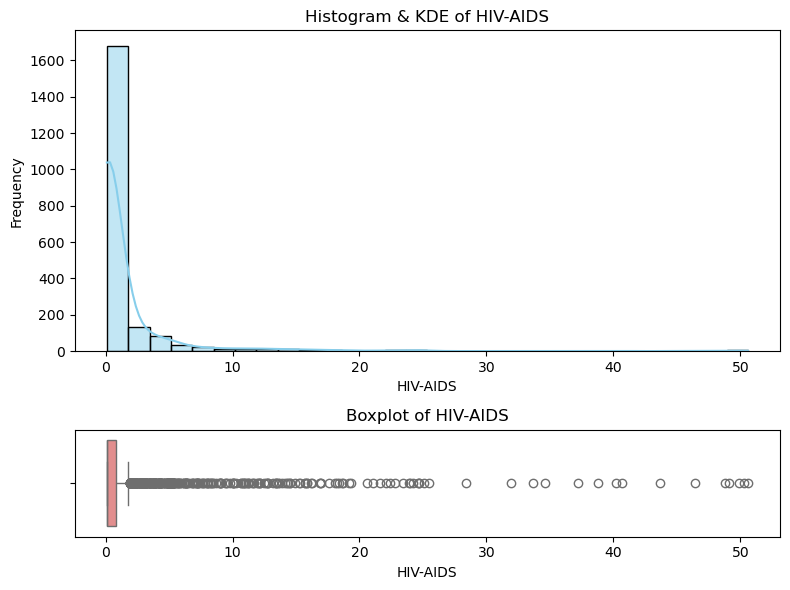

In [18]:
plot_univariate(train, 'HIV-AIDS')

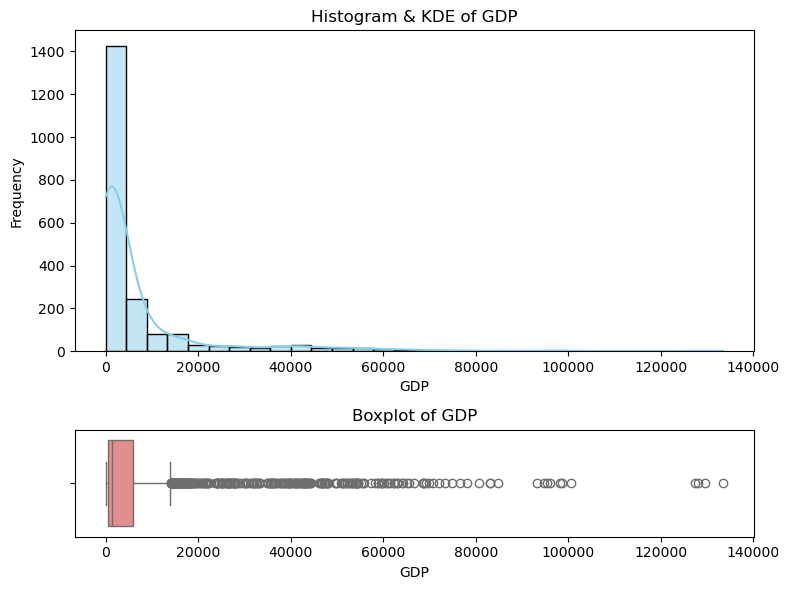

In [19]:
plot_univariate(train, 'GDP')

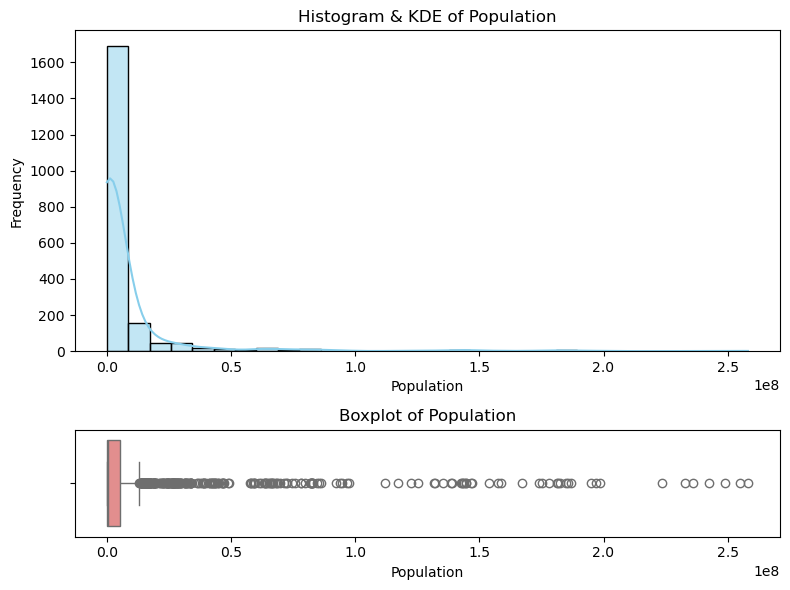

In [20]:
plot_univariate(train, 'Population')

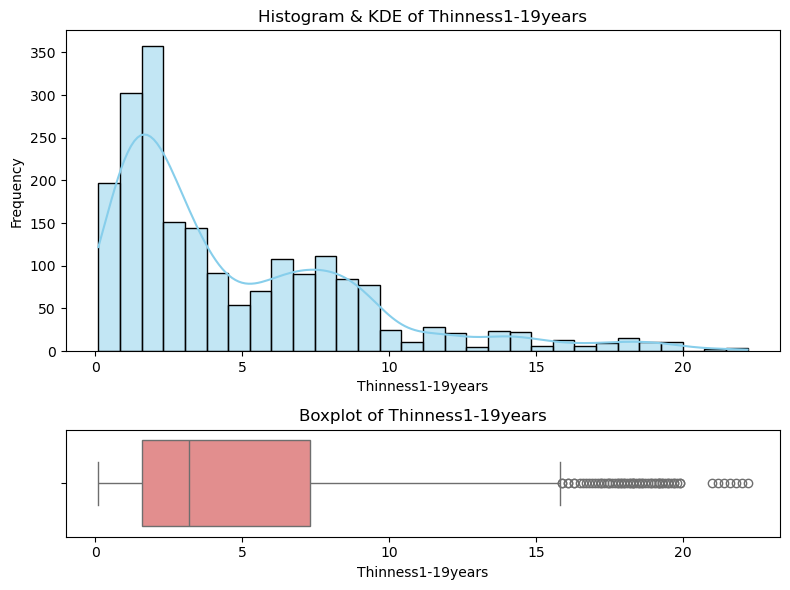

In [21]:
plot_univariate(train, 'Thinness1-19years')

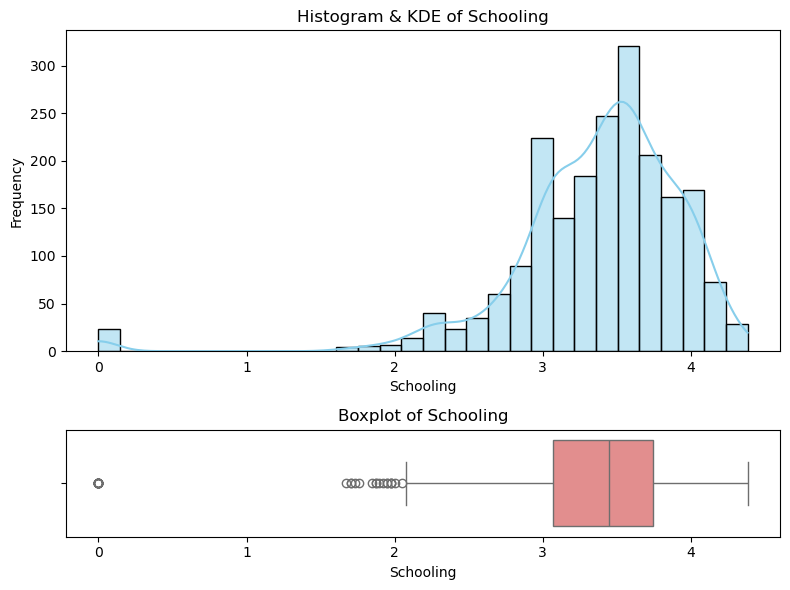

In [22]:
plot_univariate(train, 'Schooling')

**Observation:**
-	Imbalance in categorical variable:
There is a major imbalance in the feature “Status”, indicating “developed” has substantially fewer samples than “developing”. This imbalance may lead to biased model performance, potentially resulting in lower prediction accuracy for developed countries.
-	Skewed distribution:
The majority of features are highly skewed, signifying a violation of the normality assumption of linear regression, which requires transforming steps to symmetrize the distribution.
-	Outlier presence:
Outliers are prevalent across all features, suggesting the need to apply robust scaling or outlier handling techniques to minimize the impact of extreme outliers, and the risk of overfitting.


### Multivaritate analysis

In [23]:
def scatter_regression_plot(df, x_col, y_col, hue=None, size=(8, 5)):
    """
    Plots a scatter plot with a regression line.
    
    Parameters:
    - df: DataFrame containing the data
    - x_col: Column name for x-axis (numerical)
    - y_col: Column name for y-axis (numerical)
    - hue: (Optional) Categorical column for color grouping
    - size: Tuple for figure size (default is (8,5))
    """
    plt.figure(figsize=size)
    sns.lmplot(data=df, x=x_col, y=y_col, hue=hue, aspect=size[0]/size[1])
    
    plt.title(f"Regression Plot: {y_col} vs {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

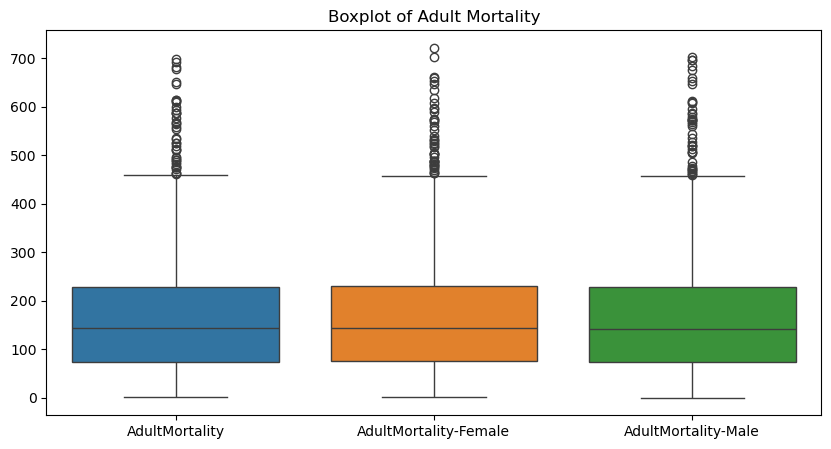

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=train[["AdultMortality", "AdultMortality-Female", 'AdultMortality-Male']])
plt.title("Boxplot of Adult Mortality")
plt.show()

Multicollinearity in Mortality Features:
Box plots of “AdultMortality”, “AdultMortality-Male”, and “AdultMortality-Female” indicate a high degree of correlation among these features, suggesting the presence of multicollinearity condition. This observation is further supported by the correlation matrix heatmap. To reduce redundancy, “AdultMortality-Male” and “AdultMortality-Female” will be removed, keeping only “AdultMortality”, which represents overall mortality across genders.

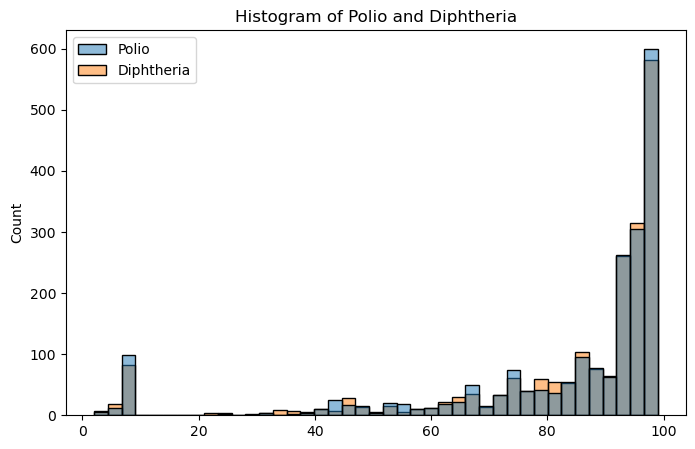

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(data=train[["Polio", "Diphtheria"]])
plt.title("Histogram of Polio and Diphtheria")
plt.show()

The Histogram of Polio and Diphtheria immunization coverage among 1-year-olds also implies a notable correlation. The correlation coefficient between them is 0.69, which, while moderately high, remains below the common threshold of 0.8 [1] for multicollinearity concerns. Therefore, both features will be retained without combining or removal.

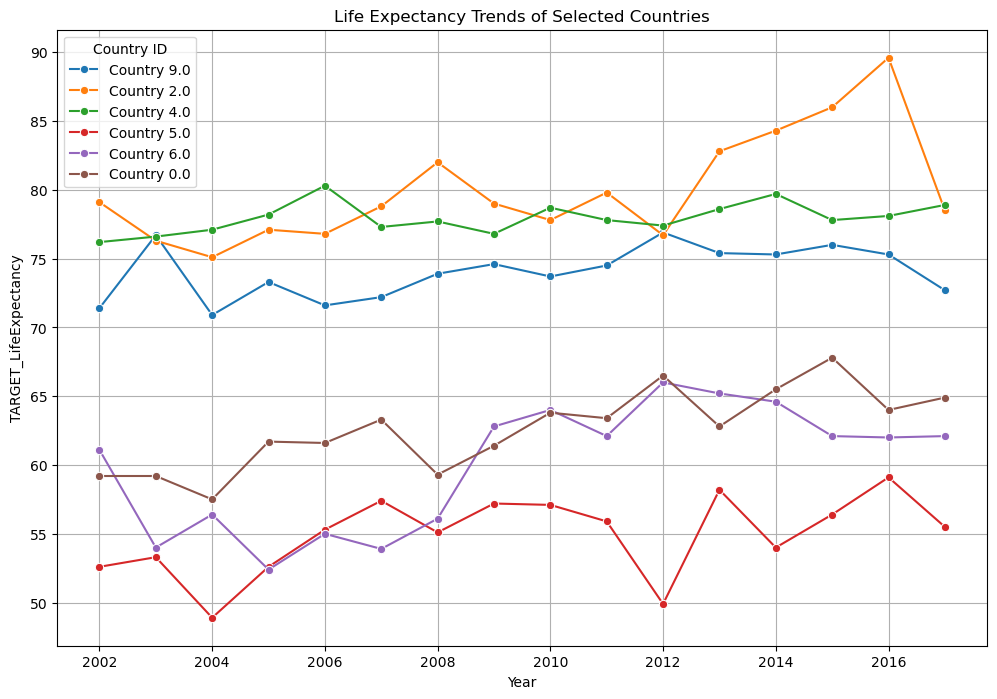

In [26]:
plt.figure(figsize=(12, 8))

countries = train[train["Country"] <= 10]
for country in countries["Country"].unique():
    subset = countries[countries["Country"] == country]
    sns.lineplot(data=subset, x="Year", y="TARGET_LifeExpectancy", label=f"Country {country}", marker="o")

# Labels and title
plt.title("Life Expectancy Trends of Selected Countries")
plt.xlabel("Year")
plt.ylabel("TARGET_LifeExpectancy")
plt.legend(title="Country ID")
plt.grid(True)

plt.show()

Life Expectancy Trends by Country:
The line plot titled “Life Expectancy Trends of Selected Countries” illustrates the temporal life expectancy patterns of six countries. It can be inferred that each line fluctuates with minimal differences between two consecutive years, with countries naturally grouped into two clusters - those with life expectancy above 70 years and those below. 

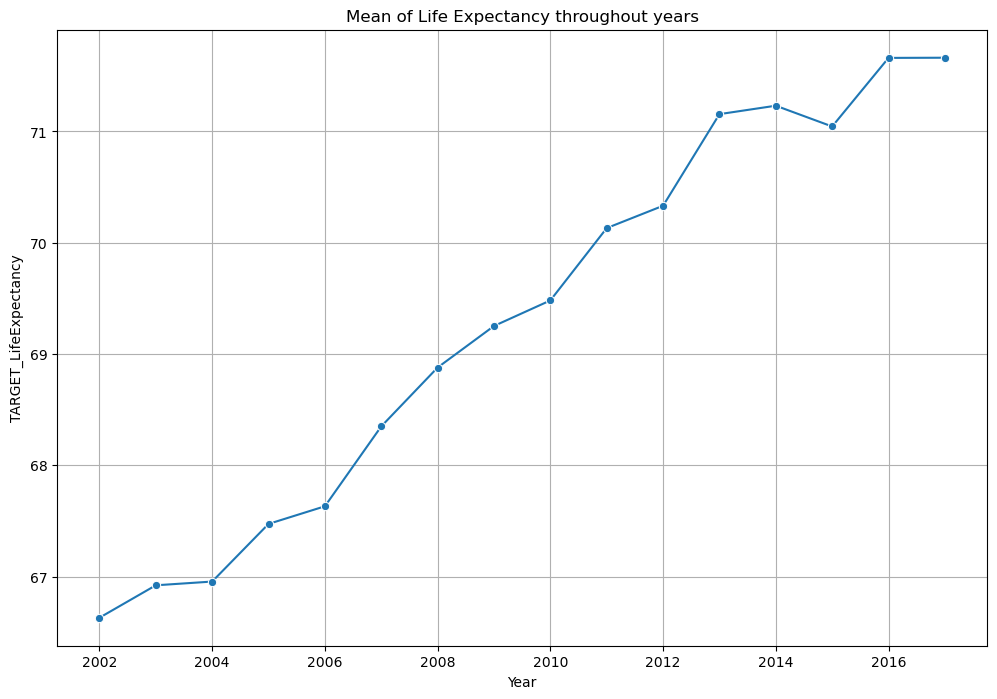

In [27]:
plt.figure(figsize=(12, 8))

subset = train.groupby("Year", as_index=False)["TARGET_LifeExpectancy"].mean()

sns.lineplot(data=subset, x="Year", y="TARGET_LifeExpectancy", marker="o")

# Labels and title
plt.title("Mean of Life Expectancy throughout years")
plt.xlabel("Year")
plt.ylabel("TARGET_LifeExpectancy")
plt.grid(True)

plt.show()

Overall Trend in Life Expectancy:
The plot “Mean of Life Expectancy Throughout the Years” demonstrates an apparent upward trend, indicating general improvements in global life expectancy over time.

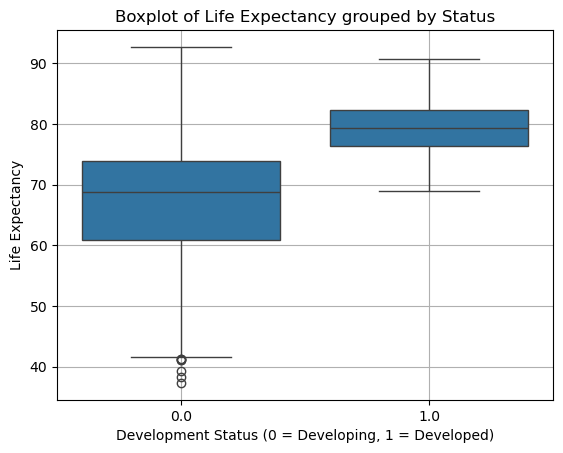

In [28]:
sns.boxplot(data=train, x="Status", y="TARGET_LifeExpectancy")

plt.title("Boxplot of Life Expectancy grouped by Status")
plt.xlabel("Development Status (0 = Developing, 1 = Developed)")
plt.ylabel("Life Expectancy")
plt.grid(True)
plt.show()

Life Expectancy in different development status:
The “Boxplot of Life Expectancy grouped by status” indicates that developed countries have significantly higher life expectancy compared to developing countries, emphasizing how socioeconomic development contributes to public health.

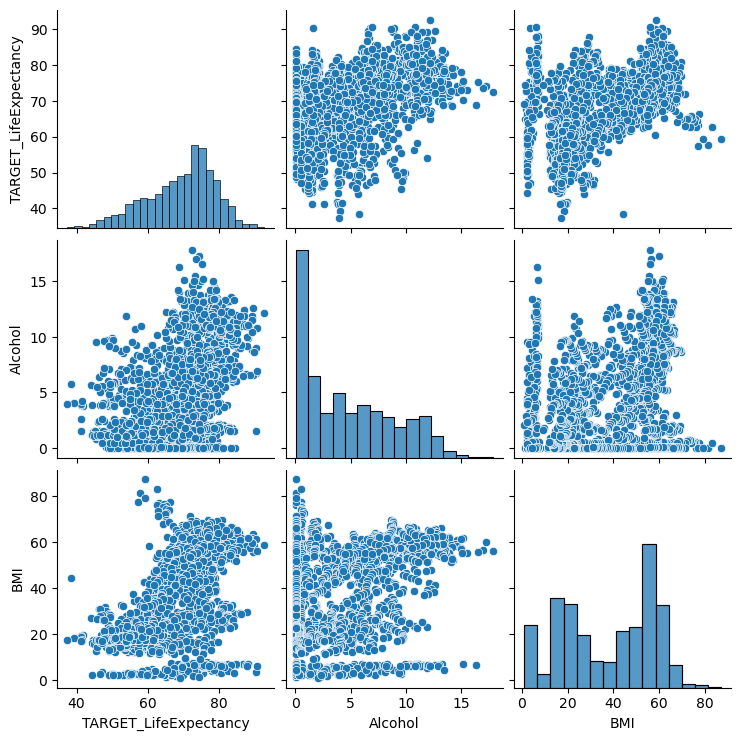

In [29]:
sns.pairplot(train[["TARGET_LifeExpectancy", 'Alcohol', 'BMI']])
plt.show()

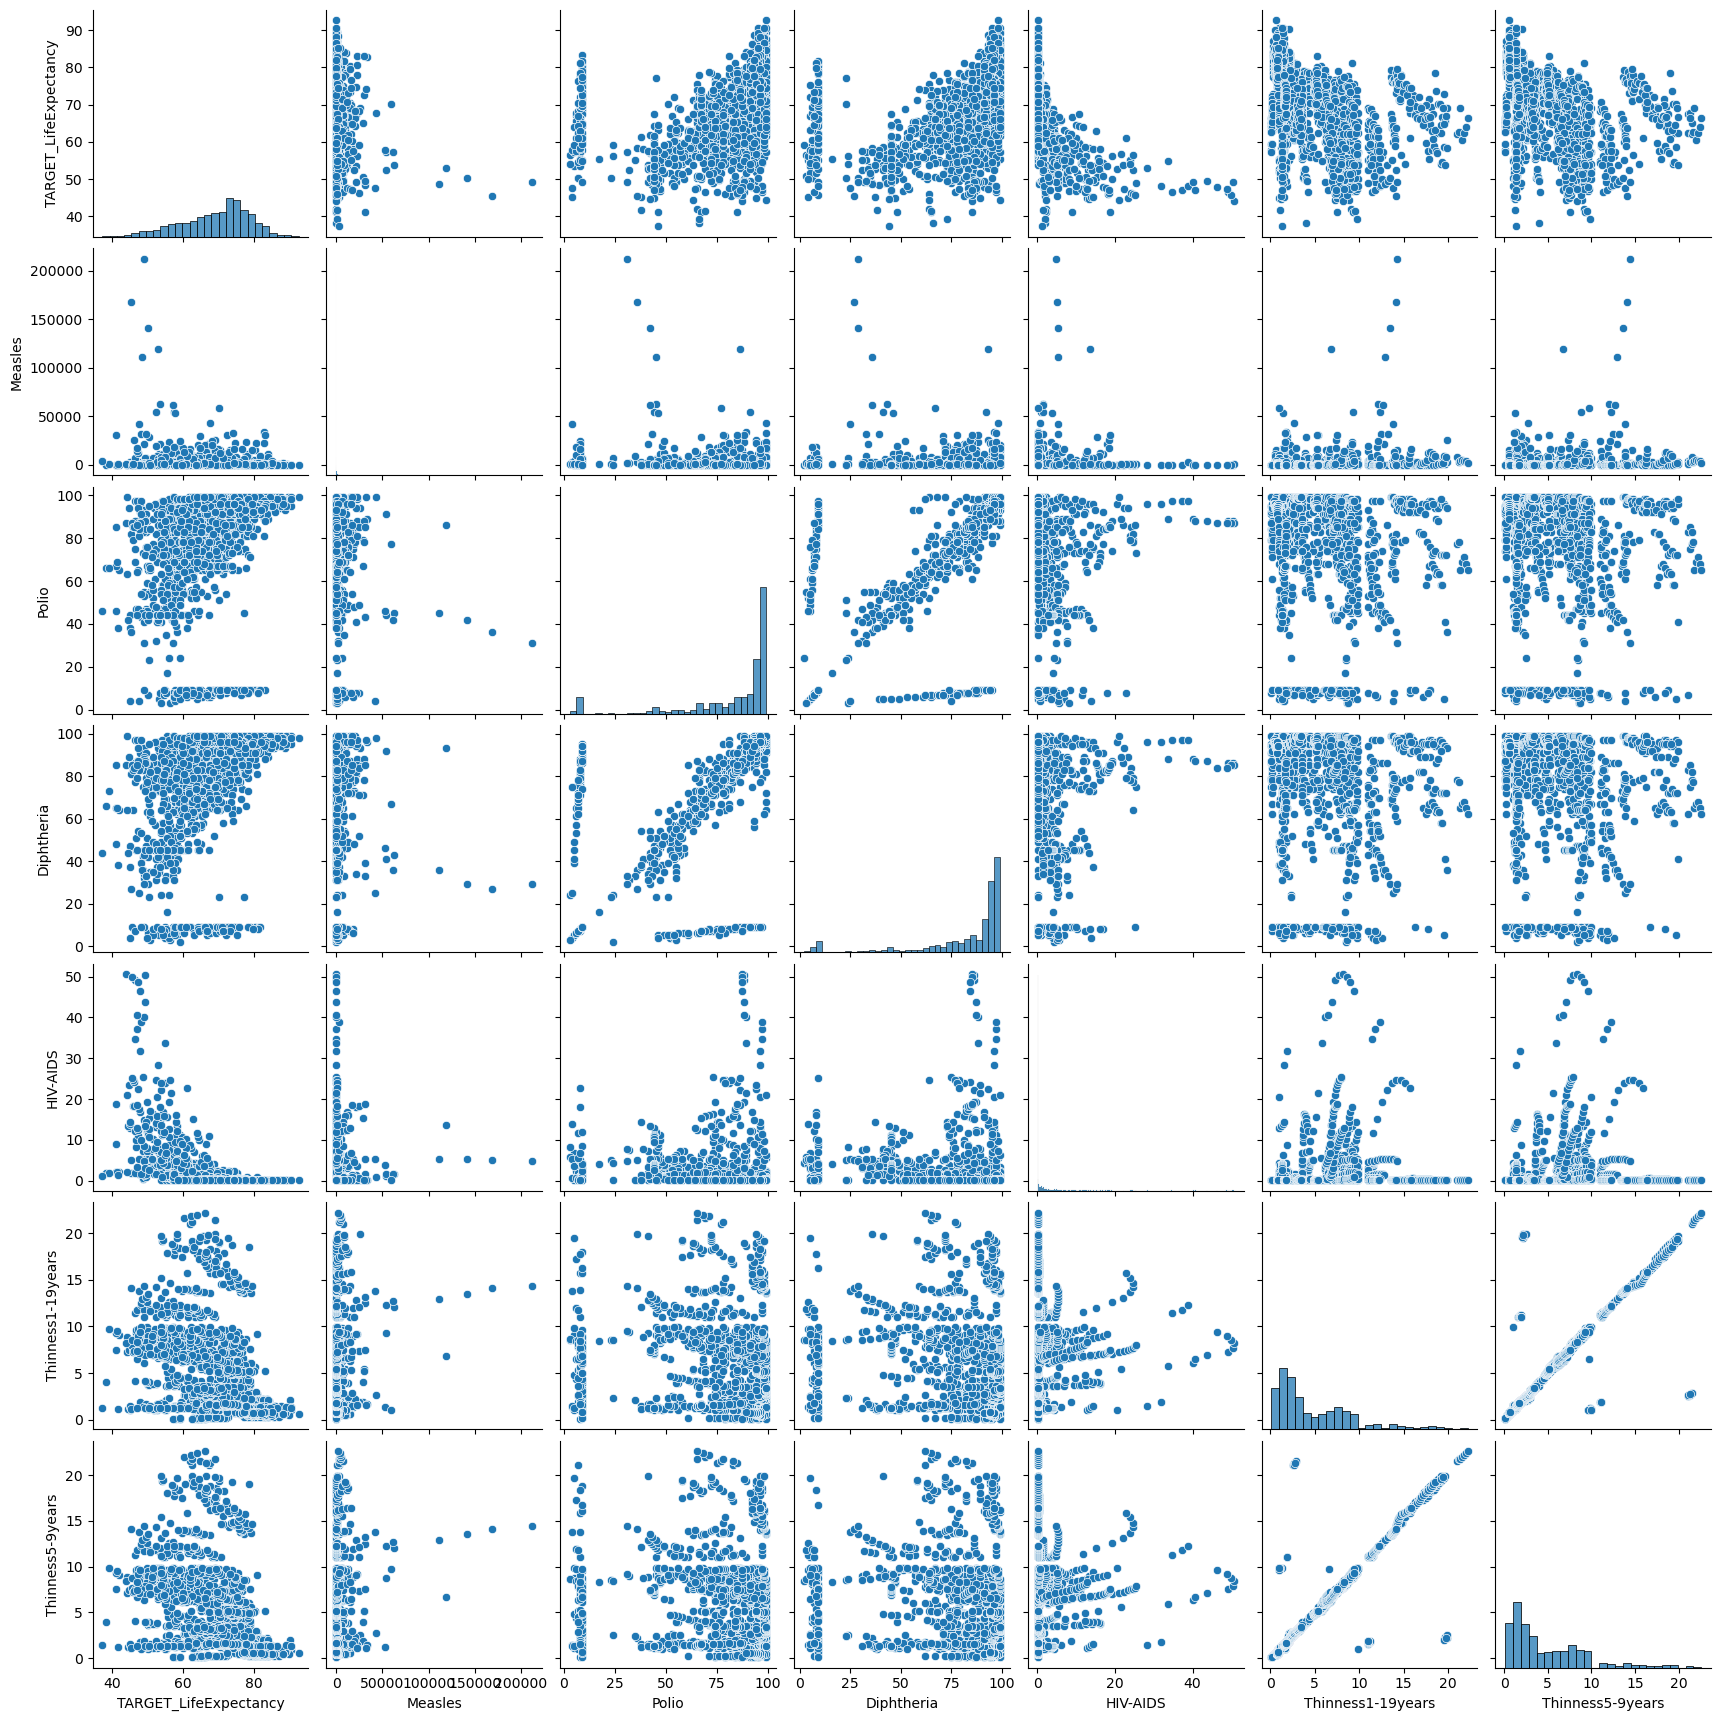

In [30]:
sns.pairplot(train[["TARGET_LifeExpectancy", 'Measles', 'Polio', 'Diphtheria', 'HIV-AIDS', 'Thinness1-19years', 'Thinness5-9years']])
plt.show()

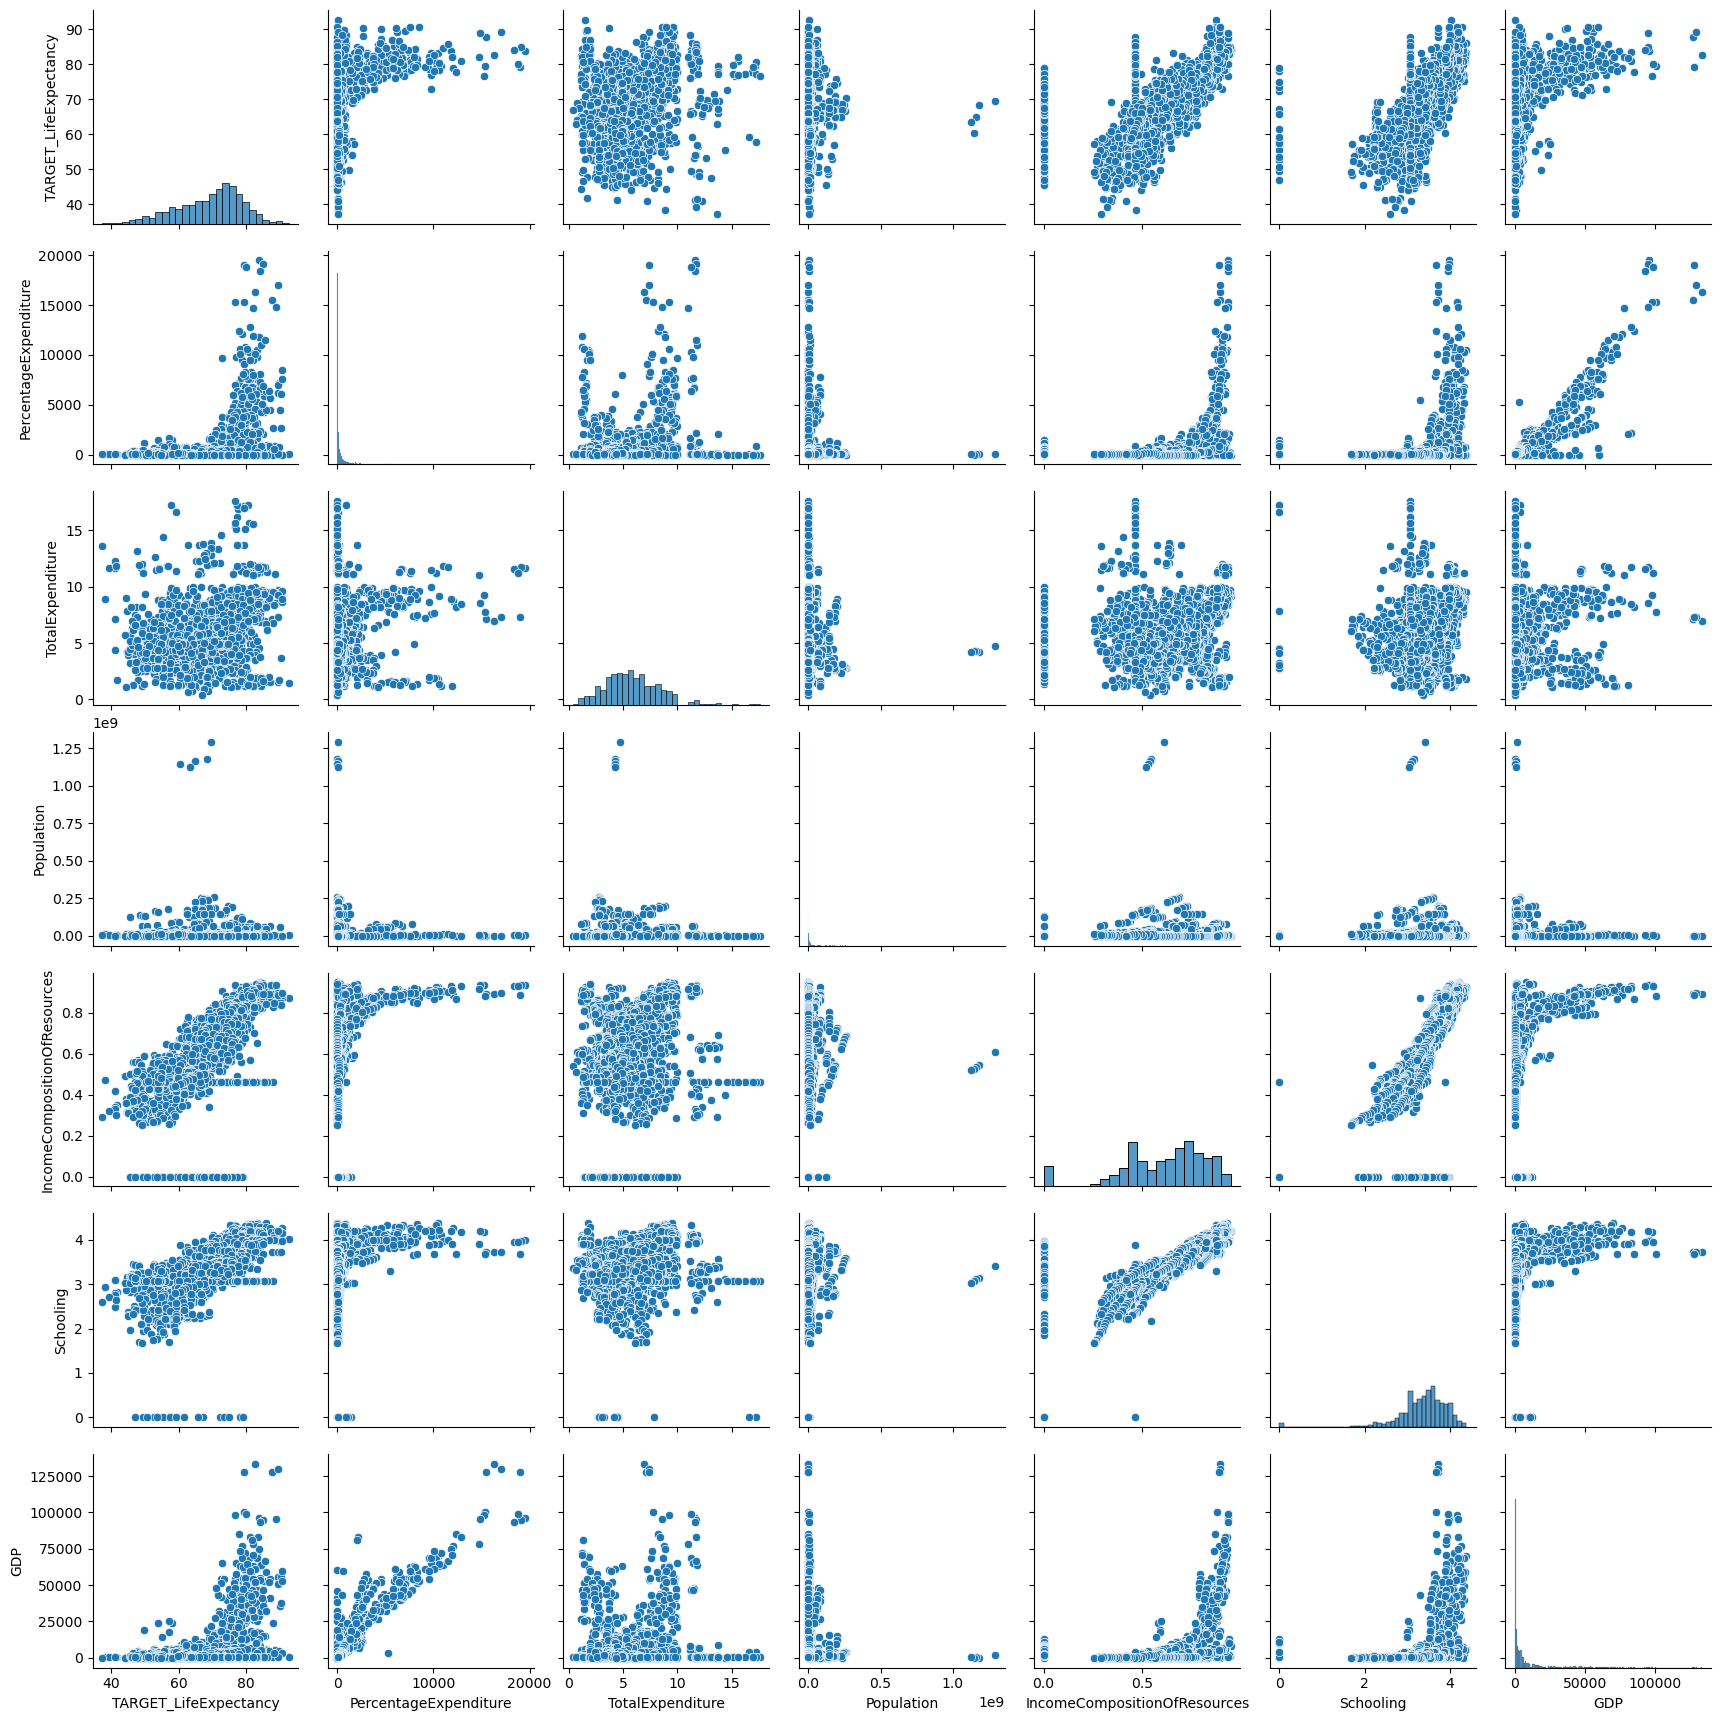

In [93]:
sns.pairplot(train[["TARGET_LifeExpectancy", 'PercentageExpenditure', 'TotalExpenditure', 'Population', 'IncomeCompositionOfResources', 'Schooling', 'GDP']])
plt.show()

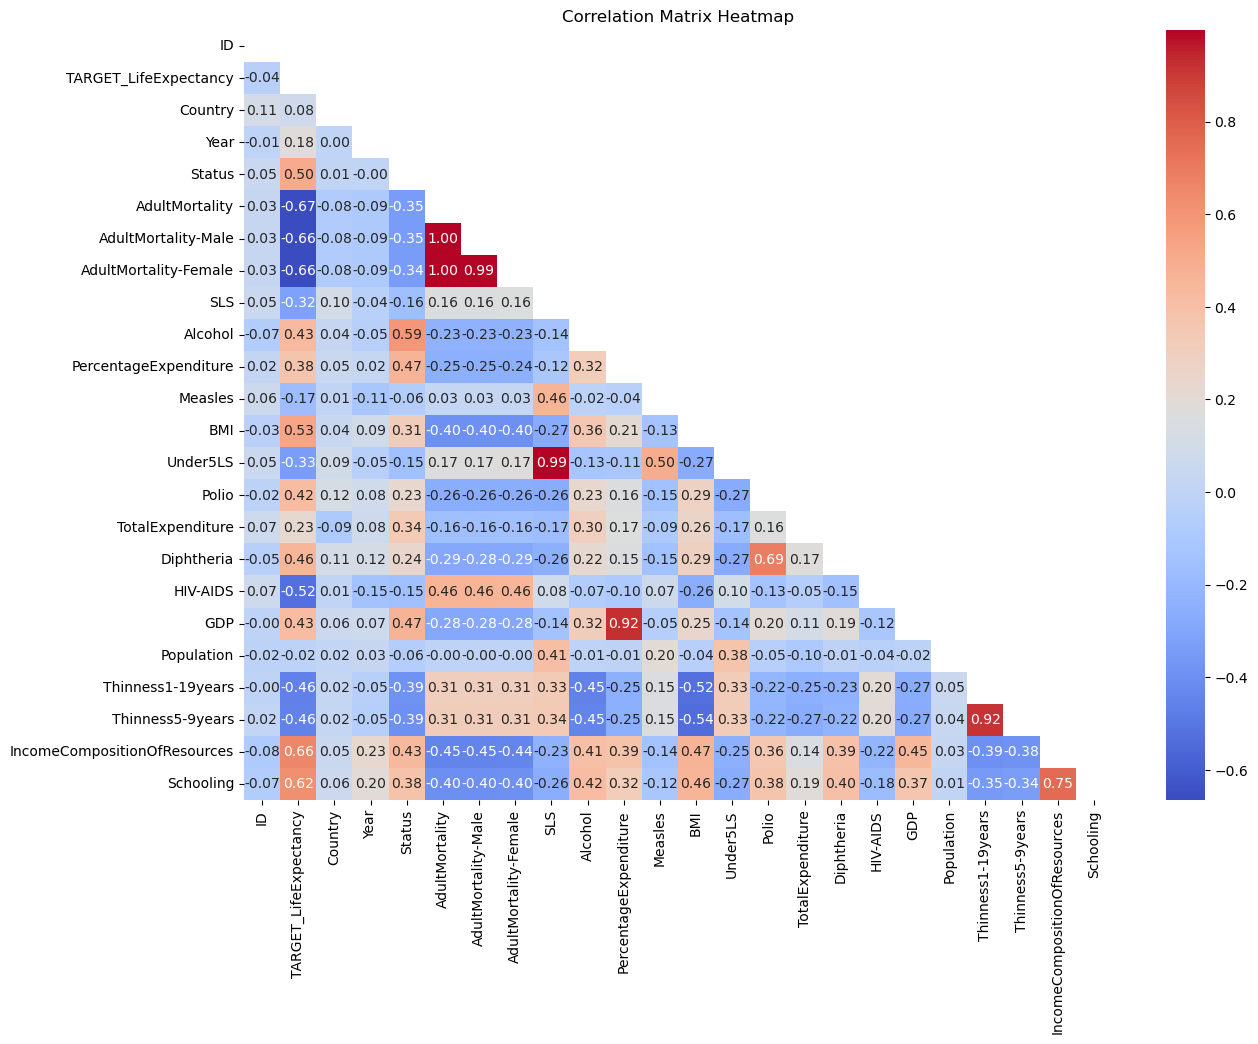

In [32]:
# Compute the correlation matrix
correlation_matrix = train.corr(numeric_only=True)

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

**Observation**
- Insights from the pair plot indicate that most features exhibit weak linear relationships with the target variable.
-	High correlations between two features: The pair plot of socioeconomic indicators reveals some notable linear relationships. In particular, “GDP” and “PercentageExpenditure”, as well as “IncomeCompositionOfResources” and “Schooling”, demonstrate strong positive correlations, with Pearson coefficients of 0.92 and 0.75, respectively.
-	Observation of the pair plot of health indicators shows that “Thinness1-19years” and “Thinness5-9years” have an extremely strong linear relationship, which can be deducted from the fact that they represent the same health metric of different age groups.
-	The correlation between “Under5LS” and “SLS” is also exceptionally high, with a coefficient of 0.99, indicating that they capture nearly identical information. 

## **Feature Engineering**

Drop unnecessary feature "ID"

In [64]:
train = train.drop('ID', axis=1)
test = test.drop('ID', axis = 1)

Drop one feature in highly correlated pairs

In [34]:
train['Thinness5-19years'] = (train['Thinness1-19years'] + train['Thinness5-9years']) / 2

In [62]:
test['Thinness5-19years'] = (test['Thinness1-19years'] + test['Thinness5-9years']) / 2

In [65]:
train = train.drop(["AdultMortality-Female", "AdultMortality-Male", 'Thinness1-19years','Thinness5-9years', 'Under5LS', 'PercentageExpenditure'], axis=1)
test = test.drop(["AdultMortality-Female", "AdultMortality-Male",'Thinness1-19years','Thinness5-9years', 'Under5LS', 'PercentageExpenditure'], axis=1)

Create train and validation set

In [37]:
X = train.drop('TARGET_LifeExpectancy', axis=1)
y = train[['TARGET_LifeExpectancy']]

In [38]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2055 entries, 0 to 2070
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2055 non-null   float64
 1   Year                          2055 non-null   float64
 2   Status                        2055 non-null   float64
 3   AdultMortality                2055 non-null   float64
 4   SLS                           2055 non-null   float64
 5   Alcohol                       2055 non-null   float64
 6   Measles                       2055 non-null   float64
 7   BMI                           2055 non-null   float64
 8   Polio                         2055 non-null   float64
 9   TotalExpenditure              2055 non-null   float64
 10  Diphtheria                    2055 non-null   float64
 11  HIV-AIDS                      2055 non-null   float64
 12  GDP                           2055 non-null   float64
 13  Populati

In [39]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2)

## **Scale and Transform**

Create scaler, transformer, polynomial features, and randomized search variable for easier integrating into pipeline.

In [36]:
scaler = RobustScaler()
transformer = QuantileTransformer(output_distribution='normal')
poly = PolynomialFeatures(degree=2)
search = RandomizedSearchCV

# **Data Modelling**

## **Fitting models**

In [40]:
def plot_cross_validated_pred(y_pred, y_valid, model_name): 
    """
    Plot prediction error diagnostics for a regression model.

    Parameters:
    - y_pred (array-like): Predicted target values from the model.
    - y_valid (array-like): Actual target values from the validation set.
    - model_name (str): Name of the model, used in plot title.

    This function creates two side-by-side plots:
    1. Actual vs. Predicted values (to assess how closely predictions match reality)
    2. Residual vs. Predicted values (to detect patterns in errors that may indicate bias or model limitations)
    """
    if isinstance(y_pred, pd.DataFrame) or isinstance(y_pred, np.ndarray):
        y_pred = np.ravel(y_pred)
    if isinstance(y_valid, pd.DataFrame) or isinstance(y_valid, np.ndarray):
        y_valid = np.ravel(y_valid)
    fig, axs = plt.subplots(ncols=2, figsize=(8, 4))

    PredictionErrorDisplay.from_predictions(
        y_valid,
        y_pred,
        kind="actual_vs_predicted",
        subsample=100,
        ax=axs[0],
        random_state=0,
    )
    axs[0].set_title("Actual vs. Predicted values")

    PredictionErrorDisplay.from_predictions(
        y_valid,
        y_pred,
        kind="residual_vs_predicted",
        subsample=100,
        ax=axs[1],
        random_state=0,
    )
    axs[1].set_title("Residual vs. Predicted values")

    fig.suptitle(f"Prediction Error Plots for {model_name}")
    plt.tight_layout()
    plt.show()

Create dictionary for models and parameter grids

In [41]:
models = {
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {
            "model__n_estimators": randint(100, 300),  
            "model__max_depth": randint(1, 21),  
            "model__max_features": [None, 'sqrt', 'log2'],  
            "model__min_samples_split": randint(2, 21),  
            "model__min_samples_leaf": randint(1, 21),  
            "model__bootstrap": [True, False],  
            "model__criterion": ['squared_error', 'absolute_error'],  
            "model__warm_start": [True, False] 
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(),
        "params": {
            "model__n_estimators": randint(1000, 2001),  
            "model__learning_rate": [0.001, 0.01, 0.1, 0.2],  
            "model__max_depth": randint(1, 11),  
            "model__min_samples_split": randint(2, 21),  
            "model__min_samples_leaf": randint(1, 21),  
            "model__subsample": [0.7, 0.8, 0.9, 1.0], 
            "model__max_features": [None, 'sqrt', 'log2'],  
            "model__loss": ['squared_error', 'absolute_error', 'huber', 'quantile']
        }
    },
    "HistGradientBoosting": {
        "model": HistGradientBoostingRegressor(),
        "params": {
            "model__max_iter": randint(100, 300),  
            "model__learning_rate": [0.001, 0.01, 0.1, 0.2],  
            "model__max_depth": randint(1, 11),  
            "model__min_samples_leaf": randint(1, 21),  
            "model__l2_regularization": [0.0, 0.1, 1.0, 10.0],  
            "model__max_bins": [8, 16, 32, 64, 128, 255],  
            "model__categorical_features": [None], 
            "model__validation_fraction": [0.1, 0.2, 0.3],
            "model__tol": [1e-4, 1e-3, 1e-2]
        }
    },
    "DecisionTree": {
        "model": DecisionTreeRegressor(),
        "params": {
            "model__max_depth": randint(1, 21),  
            "model__min_samples_split": randint(2, 21),
            "model__min_samples_leaf": randint(1, 21),
            "model__max_features": [None, "sqrt", "log2"],  
            "model__splitter": ['best', 'random'], 
            "model__random_state": [42],  
            "model__max_leaf_nodes": [None, 10, 20, 50]  
        }
    },
    "ExtraTrees": {
        "model": ExtraTreesRegressor(),
        "params": {
            "model__n_estimators": randint(500, 2001),  
            "model__max_depth": randint(1, 21),  
            "model__max_features": [None, 'sqrt', 'log2'],  
            "model__min_samples_split": randint(2, 21), 
            "model__min_samples_leaf": randint(1, 21),  
            "model__bootstrap": [True, False]
        }
    },
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9, 11],
            "model__p": [1, 2],
            "model__algorithm" :["ball_tree", "kd_tree", "brute"]
        }
    },
    "AdaBoost": {
        "model": AdaBoostRegressor(),
        "params": {
            "model__n_estimators": randint(50, 1000),              
            "model__learning_rate": uniform(0.01, 1.0),            
            "model__loss": ["linear", "square", "exponential"],    
            "model__random_state": [42]
        }
    },
    "XGBoost": {
        "model": xgb.XGBRegressor(),
        "params": {
            "model__colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
            "model__gamma": uniform(0, 0.5),
            "model__learning_rate": uniform(0.03, 0.3), 
            "model__max_depth": range(2,11,2),
            "model__n_estimators": randint(100, 150), 
            "model__subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
            "model__min_child_weight": range(2,13,2),
            "model__reg_alpha": uniform(0, 0.5),
        }
    }
}

In [42]:
regularized_models = {
    "Lasso": {
        "model": Lasso(max_iter=1000000, random_state=42), 
        "params": {
            "alphas": [0.001, 0.01, 0.1, 1]
        }
    },
    "Ridge": {
        "model": Ridge(),
        "params" : {
            "alphas": [0.00001, 0.0001, 0.001, 0.01, 0.1 , 1]
        }
    },
    "ElasticNet": {
        "model": ElasticNet(max_iter=1000000),
        "params": {
            "alphas": [0.001, 0.01, 0.1, 1, 10],
            "l1_ratio": [0.01, 0.1, 0.5, 1]
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "C": [0.1, 1, 10, 100, 1000],  
            "epsilon": [0.01, 0.1, 0.2, 0.5],  
            "gamma": ['scale', 'auto', 0.01, 0.1, 1]
        }
    }
}

Define reusable functions for model training

In [43]:
best_params_dict = {}

def train_and_plot_model(name, info, tuning, X_train, y_train, X_valid, y_valid, pipeline):
    """
    Trains a regression model (optionally with hyperparameter tuning),
    evaluates its performance on a validation set, and plots prediction diagnostics.

    Parameters:
    - name (str): Name of the model, used for logging and plotting.
    - info (dict): Contains the model instance under 'model' and parameter grid under 'params'.
    - tuning (bool): Whether to apply hyperparameter tuning using RandomizedSearchCV.
    - X_train, y_train: Training features and target.
    - X_valid, y_valid: Validation features and target.
    - pipeline (list): List of preprocessing steps to be applied before the model.
    """
    model = info["model"]
    params = info["params"]
    full_pipeline = Pipeline(pipeline + [('model', model)])
    
    if tuning:
        search = RandomizedSearchCV(full_pipeline, param_distributions=params, scoring="neg_mean_absolute_error",random_state=42, cv=5)
        search.fit(X_train, y_train.values.ravel())
        final_model = search.best_estimator_
        best_params = search.best_params_
        print(f"Best parameters for {name}: {best_params}")
        best_params_dict[name] = best_params
        
    else:
        final_model = full_pipeline
        final_model.fit(X_train, y_train.values.ravel())

    # Predict and evaluate
    y_pred = final_model.predict(X_valid)
    mse = mean_squared_error(y_valid, y_pred)
    mae = mean_absolute_error(y_valid, y_pred)
    r2 = r2_score(y_valid, y_pred)
    
    print(f"{name} MAE: {mae:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")
    plot_cross_validated_pred(y_pred, y_valid, name)

In [44]:
def train_and_plot_regularized_model(name, info, X_train, y_train, X_valid, y_valid, pipeline):
    """
    Manually trains and evaluates regularized regression models by testing combinations
    of hyperparameters. It supports SVR, ElasticNet, and other regularized linear models 
    like Lasso and Ridge. Plots model performance and prediction diagnostics.

    Parameters:
    - name (str): Name of the model (e.g., 'SVR', 'ElasticNet', 'Lasso', etc.)
    - info (dict): Contains the base model and its hyperparameter grid under 'model' and 'params'
    - X_train, y_train: Training data
    - X_valid, y_valid: Validation data
    - pipeline (list): Preprocessing pipeline to apply before the model
    """
    base_model = info["model"]
    params = info["params"]
    results = []
    best_pred = None
    
    best_mae = float('inf')
    
    if name == "SVR":
        cs = params["C"]
        epsilons = params["epsilon"]
        gammas = params["gamma"]
        for c in cs:
            for epsilon in epsilons:
                for gamma in gammas:
                    model = clone(base_model)
                    model.set_params(C=c, epsilon=epsilon, gamma=gamma)
                    full_pipeline = Pipeline(pipeline + [('model', model)])
                    full_pipeline.fit(X_train, y_train.values.ravel())
                    y_pred = full_pipeline.predict(X_valid)
                    mse = mean_squared_error(y_valid, y_pred)
                    mae = mean_absolute_error(y_valid, y_pred)
                    r2 = r2_score(y_valid, y_pred)
                    if mae < best_mae:
                        best_mae = mae
                        best_pred = y_pred

                    results.append((c, epsilon, gamma, mae, mse, r2))

        best = min(results, key=lambda x: x[3])
        print(f"Results: {results}")
        print(f"Best parameter: C - {best[0]}, epsilon - {best[1]}, gamma - {best[2]}, MAE - {best[3]:.4f}, MSE: {best[4]:.4f}, R²: {best[5]:.4f}")

    elif name == "ElasticNet":
        alphas = params["alphas"]
        l1_ratios = params["l1_ratio"]

        alpha_grid, l1_grid = np.meshgrid(alphas, l1_ratios)
        Z = np.zeros_like(alpha_grid)

        results = []

        for i in range(len(l1_ratios)):
            for j in range(len(alphas)):
                alpha = alphas[j]
                l1_ratio = l1_ratios[i]

                model = clone(base_model)
                model.set_params(alpha=alpha, l1_ratio=l1_ratio)
                full_pipeline = Pipeline(pipeline + [('model', model)])
                full_pipeline.fit(X_train, y_train)
                y_pred = full_pipeline.predict(X_valid)
                mse = mean_squared_error(y_valid, y_pred)
                mae = mean_absolute_error(y_valid, y_pred)
                r2 = r2_score(y_valid, y_pred)
                if mae < best_mae:
                    best_mae = mae
                    best_pred = y_pred

                results.append((alpha, l1_ratio, mae, mse, r2))
                Z[i, j] = mae 

        best = min(results, key=lambda x: x[2])
        print(f"Results: {results}")
        print(f"Best parameter - alpha: {best[0]}, l1_ratio: {best[1]}, MAE: {best[2]:.4f}, MSE: {best[3]:.4f}, R²: {best[4]:.4f}")

        # Plotting the 3D wireframe
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_wireframe(alpha_grid, l1_grid, Z, rstride=1, cstride=1)

        ax.set_xlabel('Alpha')
        ax.set_ylabel('L1 Ratio')
        ax.set_zlabel('MAE')
        ax.set_title('ElasticNet Performance')

        plt.show()


    else:
        alphas = params["alphas"]
        for alpha in alphas:
            model = clone(base_model)
            model.set_params(alpha=alpha)
            full_pipeline = Pipeline(pipeline + [('model', model)])
            full_pipeline.fit(X_train, y_train)
            y_pred = full_pipeline.predict(X_valid)
            mse = mean_squared_error(y_valid, y_pred)
            mae = mean_absolute_error(y_valid, y_pred)
            r2 = r2_score(y_valid, y_pred)
            if mae < best_mae:
                best_mae = mae
                best_pred = y_pred
            results.append((alpha, mae, mse, r2))

        best = min(results, key=lambda x: x[1])
        print(f"Results: {results}")
        print(f"Best parameter - alpha: {best[0]}, MAE - {best[1]:.4f}, MSE: {best[2]:.4f}, R²: {best[3]:.4f}")
        alphas, mae_values, mse_values, r2_values = zip(*results)  
        
        # Plotting the performance
        plt.figure(figsize=(16, 6))
        plt.plot(alphas, mae_values, label=f"Performance of {name}")
        plt.xlabel('Alpha')
        plt.ylabel('MAE')
        plt.title(f"{name} Performance")
        plt.show()
    plot_cross_validated_pred(best_pred, y_valid, name)

### *Base models*

Training base LinearRegression base model...
LinearRegression base model MAE: 3.9666, MSE: 25.0812, R²: 0.6898


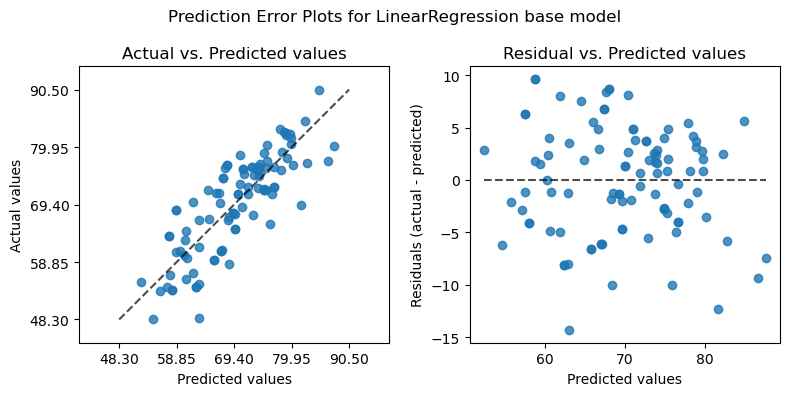

In [45]:
model_name = "LinearRegression base model"
print(f"Training base {model_name}...")
pipeline_steps = [
    ("scaler", scaler),
    ("transformer", transformer)
]
train_and_plot_model(
    name=model_name,
    info={'model': LinearRegression(), 'params': None}, 
    tuning=False, 
    X_train=X_train, 
    y_train=y_train, 
    X_valid=X_valid,
    y_valid=y_valid,
    pipeline=pipeline_steps
)


Training base RandomForest base model...
RandomForest base model MAE: 2.0673, MSE: 7.2535, R²: 0.9103


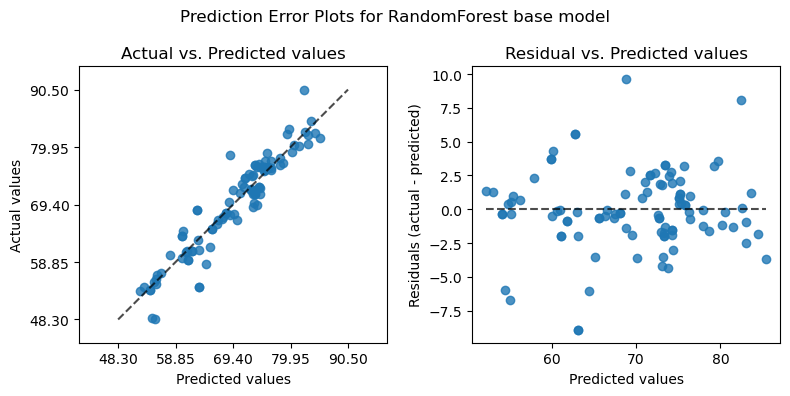

Training base GradientBoosting base model...
GradientBoosting base model MAE: 2.2764, MSE: 8.1519, R²: 0.8992


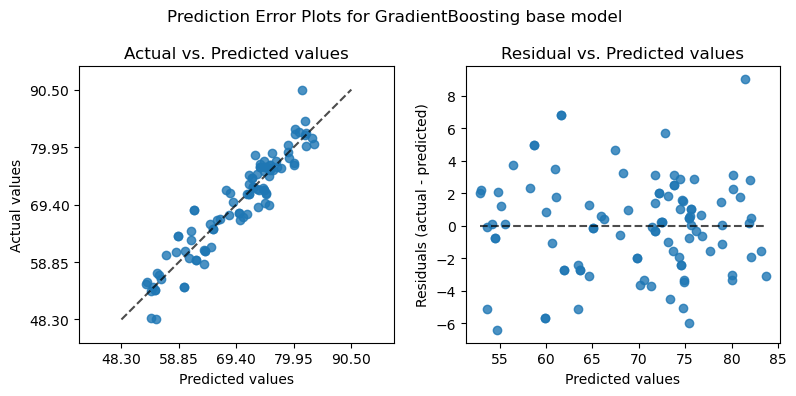

Training base HistGradientBoosting base model...
HistGradientBoosting base model MAE: 2.1428, MSE: 7.4188, R²: 0.9082


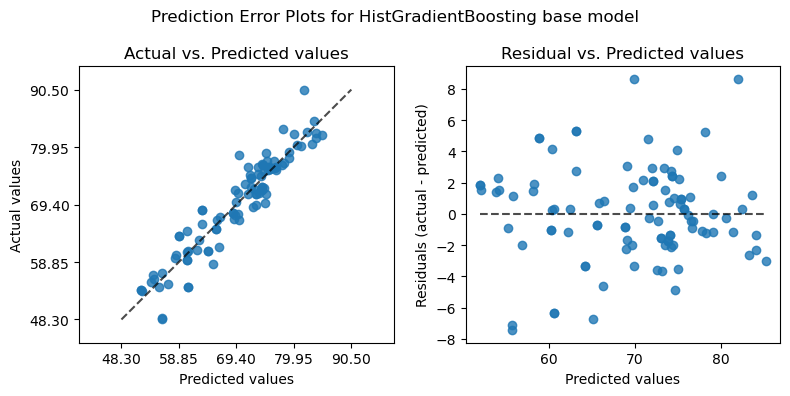

Training base DecisionTree base model...
DecisionTree base model MAE: 3.0764, MSE: 15.8567, R²: 0.8039


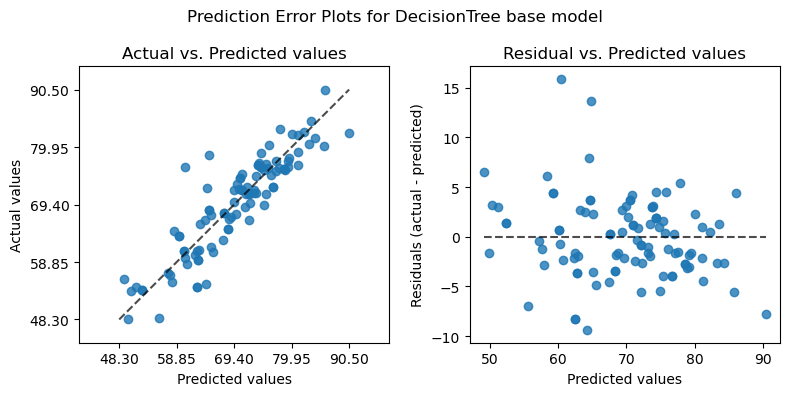

Training base ExtraTrees base model...
ExtraTrees base model MAE: 1.9475, MSE: 6.3520, R²: 0.9214


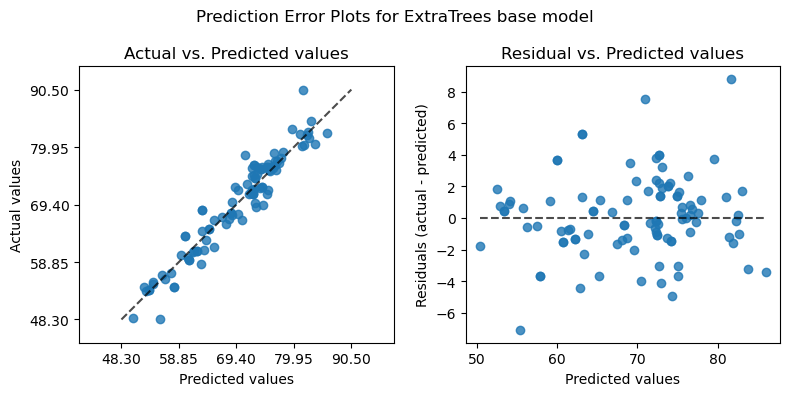

Training base KNN base model...
KNN base model MAE: 2.7231, MSE: 13.0332, R²: 0.8388


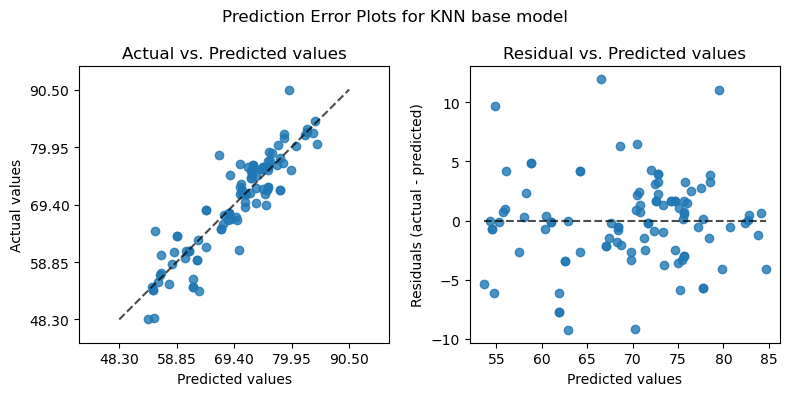

Training base AdaBoost base model...
AdaBoost base model MAE: 2.6867, MSE: 11.0013, R²: 0.8639


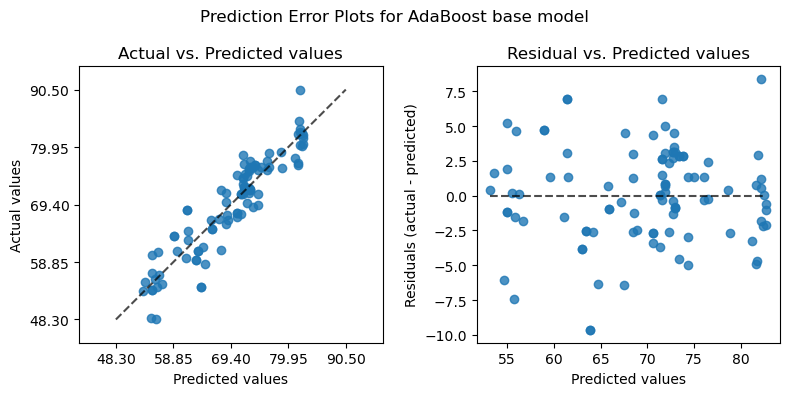

Training base XGBoost base model...
XGBoost base model MAE: 2.3206, MSE: 8.6660, R²: 0.8928


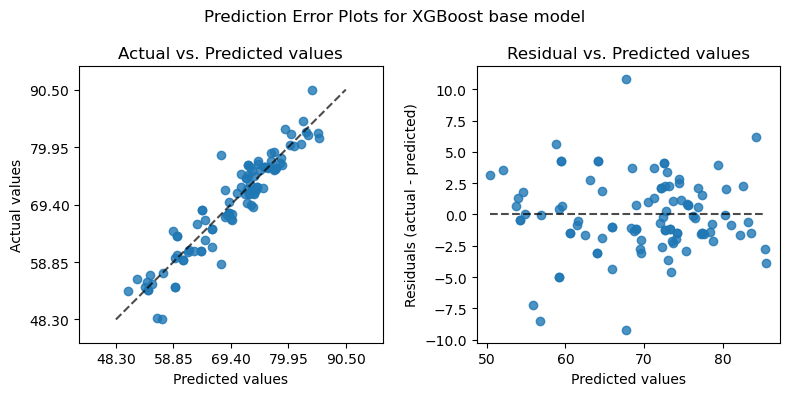

In [46]:
for name, info in models.items():
    model_name = f"{name} base model"
    print(f"Training base {model_name}...")
    pipeline_steps = [
        ("scaler", scaler),
        ("transformer", transformer)
    ]
    train_and_plot_model(
        name=model_name,
        info=info, 
        tuning=False, 
        X_train=X_train, 
        y_train=y_train, 
        X_valid=X_valid,
        y_valid=y_valid,
        pipeline=pipeline_steps
    )

### **Regularized models**

Traing Lasso base model...
Results: [(0.001, 3.9664996997236663, 25.08012469931532, 0.6898171563096925), (0.01, 3.966256267056387, 25.071387086780003, 0.6899252202661426), (0.1, 3.9703109535140637, 25.051240961017818, 0.6901743810120788), (1, 4.155497017795226, 27.01886206709485, 0.665839481672256)]
Best parameter - alpha: 0.01, MAE - 3.9663, MSE: 25.0714, R²: 0.6899


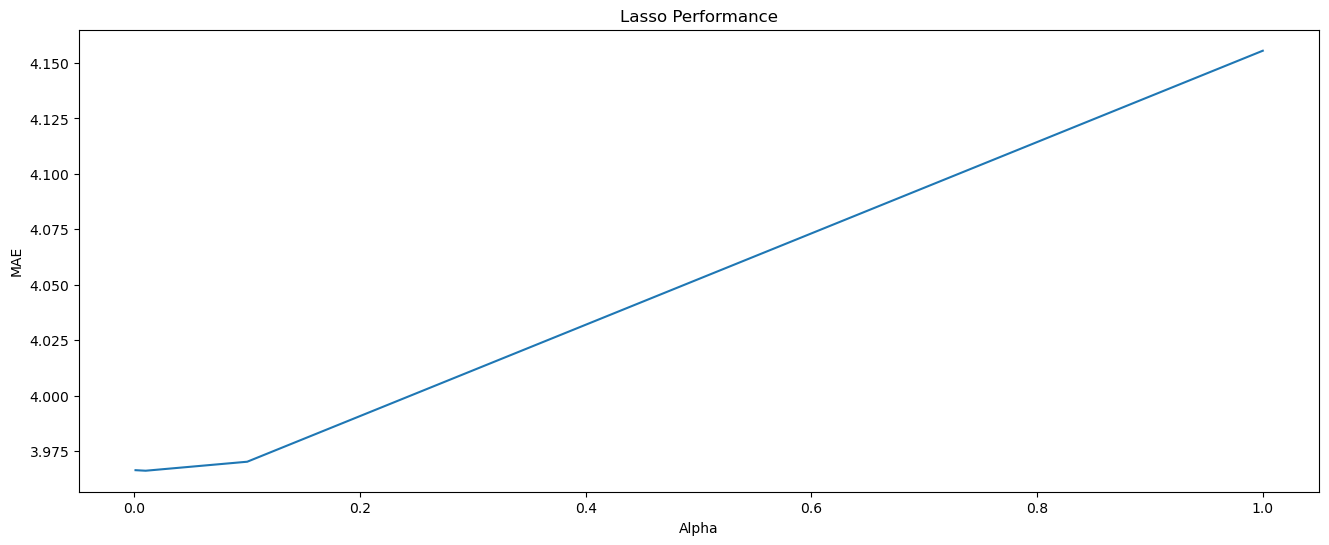

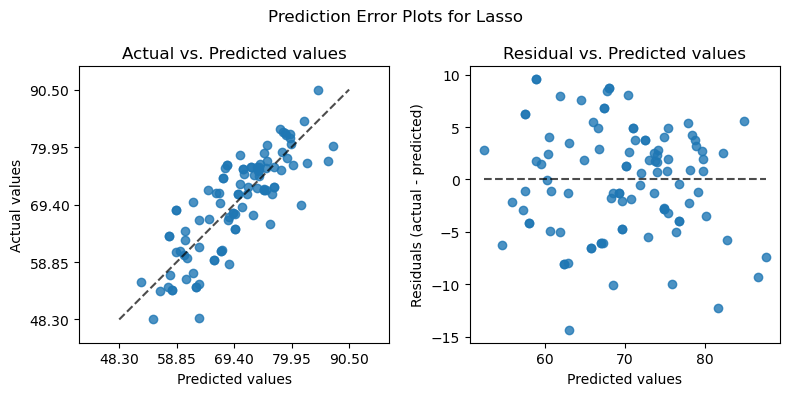

Traing Ridge base model...
Results: [(1e-05, 3.9665540220498796, 25.081245911723016, 0.6898032895184716), (0.0001, 3.9665540186106654, 25.08124569196114, 0.6898032922364152), (0.001, 3.9665539842185575, 25.081243494347635, 0.6898033194157859), (0.01, 3.9665536403006008, 25.08122151873859, 0.6898035912029874), (0.1, 3.9665502014330607, 25.081001815233268, 0.6898063084246466), (1, 3.966515843934481, 25.078810029457884, 0.6898334157198742)]
Best parameter - alpha: 1, MAE - 3.9665, MSE: 25.0788, R²: 0.6898


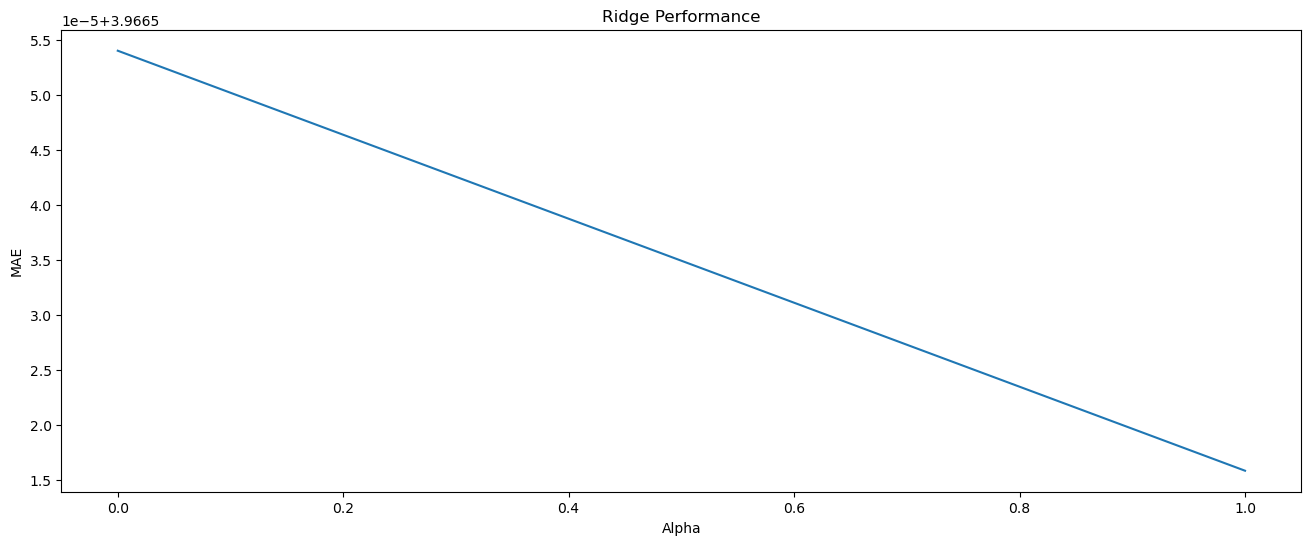

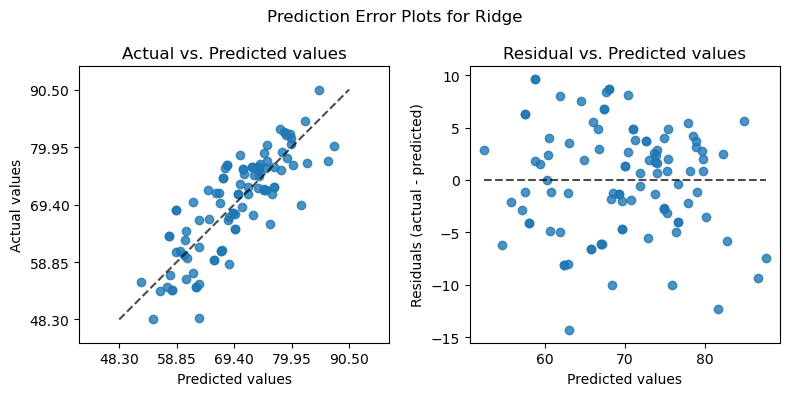

Traing ElasticNet base model...
Results: [(0.001, 0.01, 3.9664914147059704, 25.07727643085249, 0.6898523827697675), (0.01, 0.01, 3.9659356810494777, 25.04292227911201, 0.6902772637704477), (0.1, 0.01, 3.9640273204933503, 24.805045561835993, 0.6932192458178656), (1, 0.01, 4.046574708648892, 25.056941131364347, 0.6901038831549589), (10, 0.01, 4.608922315538492, 33.0618458173442, 0.5911018196191709), (0.001, 0.1, 3.9664920628401172, 25.07753520995512, 0.6898491822738009), (0.01, 0.1, 3.9659425243298756, 25.045349994509266, 0.6902472385742169), (0.1, 0.1, 3.9643000272785636, 24.819633976592854, 0.693038821038146), (1, 0.1, 4.049816898167205, 25.138577616772423, 0.6890942295947654), (10, 0.1, 4.736935580950575, 35.075292064669, 0.5662001698028192), (0.001, 0.5, 3.9664946836959696, 25.078675044222578, 0.6898350851734613), (0.01, 0.5, 3.9659724496680107, 25.056560271808657, 0.6901085935023533), (0.1, 0.5, 3.966405553473288, 24.9039137113068, 0.6919964766282815), (1, 0.5, 4.090269382489353, 25

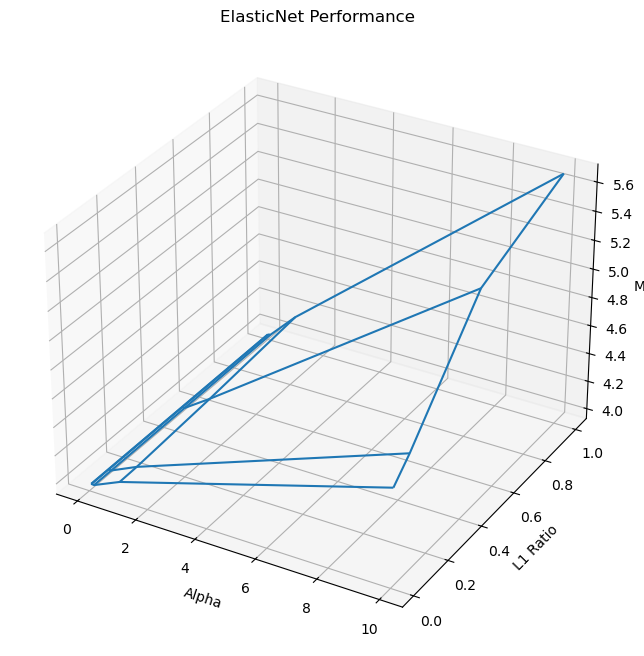

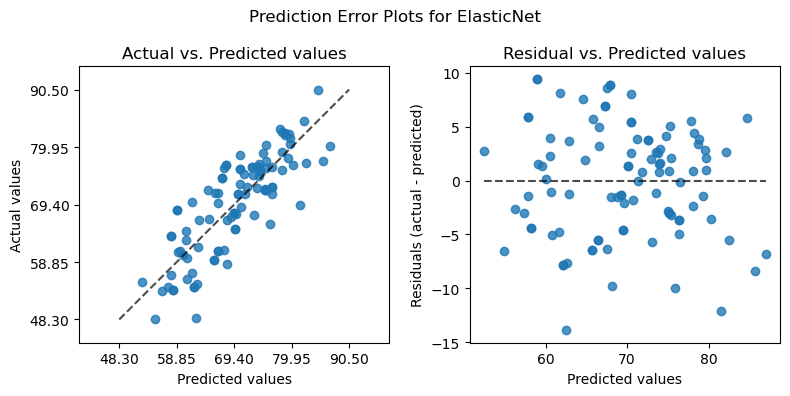

Traing SVR base model...
Results: [(0.1, 0.01, 'scale', 4.103946586465649, 27.86427661305975, 0.6553836689078283), (0.1, 0.01, 'auto', 5.187880888150342, 46.79821505956974, 0.4212148623326344), (0.1, 0.01, 0.01, 4.103103012347494, 27.535063232795856, 0.6594552731640041), (0.1, 0.01, 0.1, 5.906054633336366, 58.72260046320914, 0.27373793316644734), (0.1, 0.01, 1, 7.171654416871571, 83.02875098497542, -0.026872649053342856), (0.1, 0.1, 'scale', 4.106547569369297, 27.880188704394833, 0.6551868733257269), (0.1, 0.1, 'auto', 5.183065798696846, 46.75371073849001, 0.421765277333936), (0.1, 0.1, 0.01, 4.111610772380347, 27.659902037065496, 0.657911307343439), (0.1, 0.1, 0.1, 5.9115585772734525, 58.69689565255039, 0.27405584192337107), (0.1, 0.1, 1, 7.172218132136434, 82.95044375927178, -0.025904170696817053), (0.1, 0.2, 'scale', 4.108324265723032, 27.913832025867812, 0.6547707836431281), (0.1, 0.2, 'auto', 5.1845999059628, 46.798938325951426, 0.42120591720872824), (0.1, 0.2, 0.01, 4.12132277187

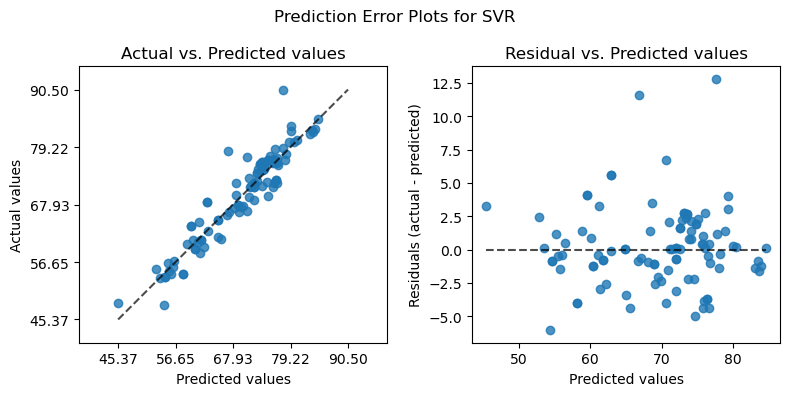

In [47]:
for name, info in regularized_models.items():
    print(f"Traing {name} base model...")
    pipeline_steps = [
        ("scaler", scaler),
        ("transformer", transformer)
    ]
    train_and_plot_regularized_model(name, info, X_train, y_train, X_valid, y_valid, pipeline_steps)

### **Polynomial Regression**

Training base Linear polynomial regression...
Linear polynomial regression MAE: 2.7901, MSE: 13.3722, R²: 0.8346


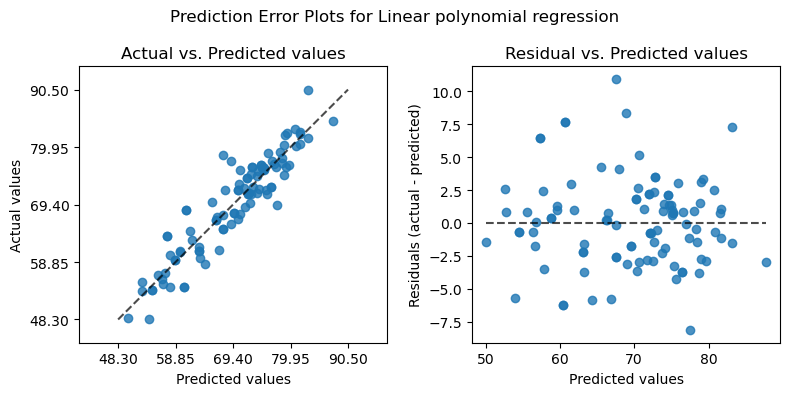

In [78]:
model_name = "Linear polynomial regression"
print(f"Training base {model_name}...")
pipeline_steps = [
    ("scaler", scaler),
    ("transformer", transformer),
    ("poly", poly)
]
train_and_plot_model(
    name=model_name,
    info={'model': LinearRegression(), 'params': None}, 
    tuning=False, 
    X_train=X_train, 
    y_train=y_train, 
    X_valid=X_valid,
    y_valid=y_valid,
    pipeline=pipeline_steps
)

Training Lasso polynomial regression...
Results: [(0.001, 2.65461118381542, 12.380227377742324, 0.8468853652204709), (0.01, 2.6134018632626517, 12.081756857556387, 0.8505767517593714), (0.1, 2.6242155579211945, 12.210616651765177, 0.8489830556400646), (1, 3.578443185070662, 20.664634348958792, 0.7444265081203751)]
Best parameter - alpha: 0.01, MAE - 2.6134, MSE: 12.0818, R²: 0.8506


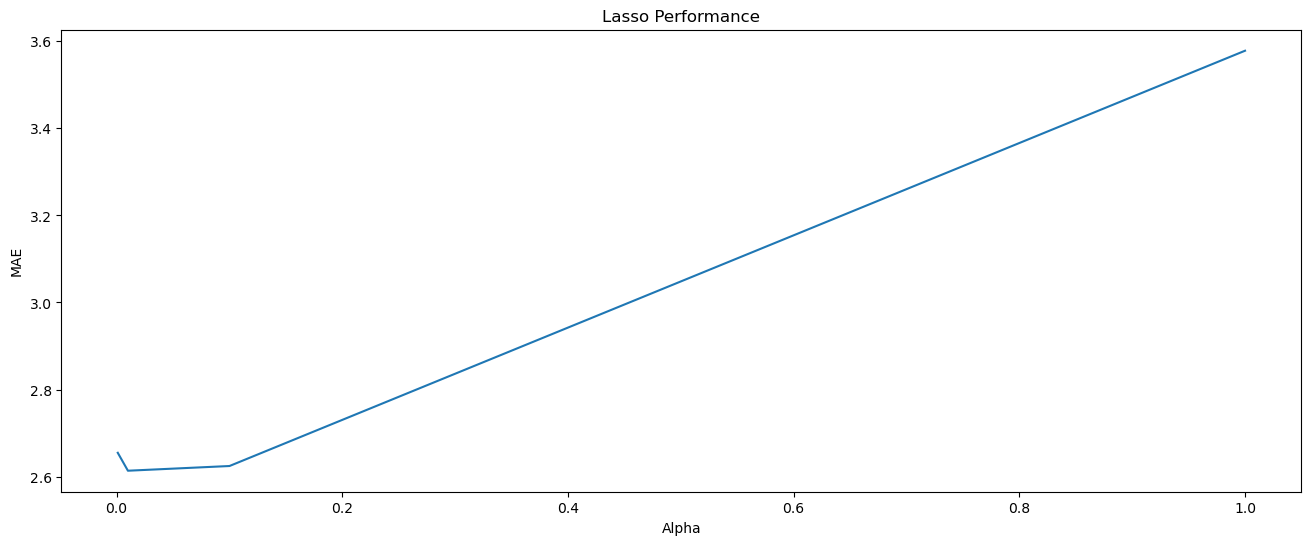

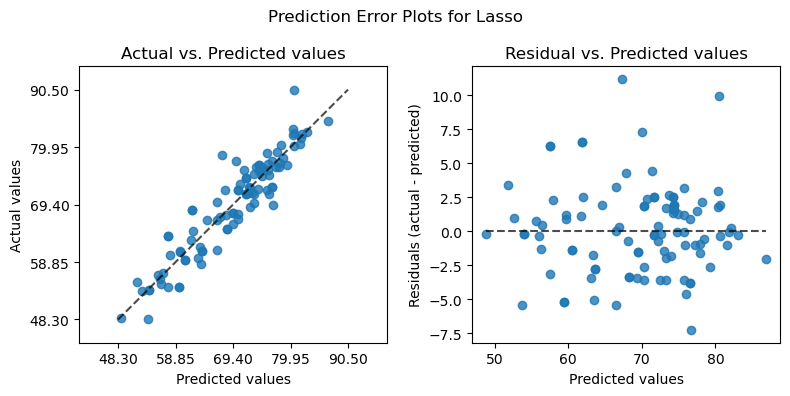

Training Ridge polynomial regression...
Results: [(1e-05, 2.66174264861973, 12.428348036567462, 0.8462902245274487), (0.0001, 2.661742450114648, 12.428346919100111, 0.8462902383479223), (0.001, 2.6617404650885113, 12.428335744760838, 0.8462903765485243), (0.01, 2.6617206172977195, 12.428224034819522, 0.8462917581408282), (0.1, 2.6615223860186408, 12.427110272857549, 0.8463055327873542), (1, 2.659578600488214, 12.416298883793235, 0.8464392445389669)]
Best parameter - alpha: 1, MAE - 2.6596, MSE: 12.4163, R²: 0.8464


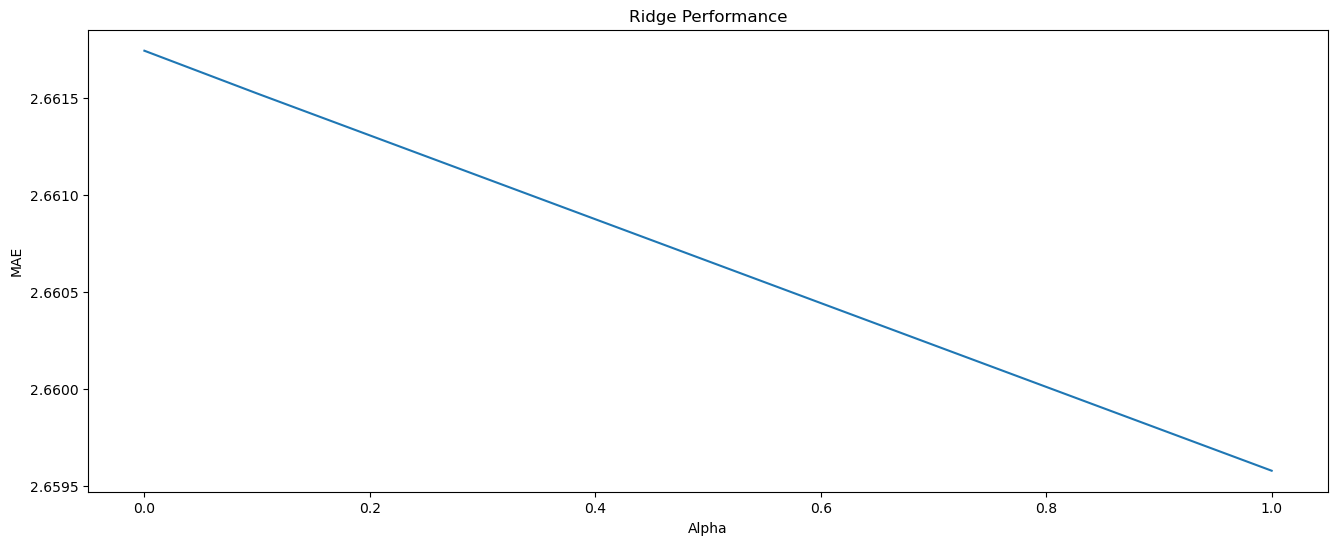

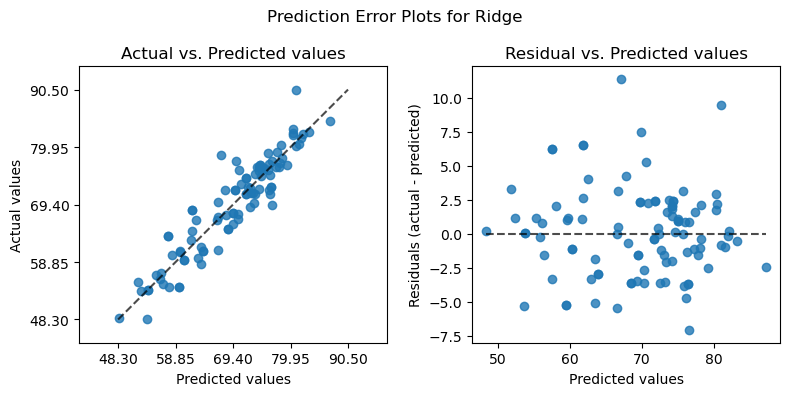

Training ElasticNet polynomial regression...
Results: [(0.001, 0.01, 2.6581995402482597, 12.408625153669595, 0.846534150742983), (0.01, 0.01, 2.6351145711180317, 12.294753633560461, 0.8479424767519742), (0.1, 0.01, 2.6236552059008154, 12.389438157257365, 0.84677144928836), (1, 0.01, 3.0028138010699177, 14.806637862786967, 0.8168763077203831), (10, 0.01, 3.8957736239231666, 23.606760452080284, 0.708039247207489), (0.001, 0.1, 2.6578692519346823, 12.406032555484723, 0.846566215156026), (0.01, 0.1, 2.632223890193405, 12.270726094156437, 0.8482396415623001), (0.1, 0.1, 2.6139764837903896, 12.291050699135415, 0.8479882734433276), (1, 0.1, 3.0739327570592114, 15.362532056264552, 0.8100011887251208), (10, 0.1, 4.2181308043088706, 27.717167822380805, 0.657203062693613), (0.001, 0.5, 2.6564044630031054, 12.394579769019506, 0.8467078595025574), (0.01, 0.5, 2.6228193426733295, 12.177440124192701, 0.8493933721671783), (0.1, 0.5, 2.6094715687656707, 12.226575646263594, 0.8487856799748594), (1, 0.5,

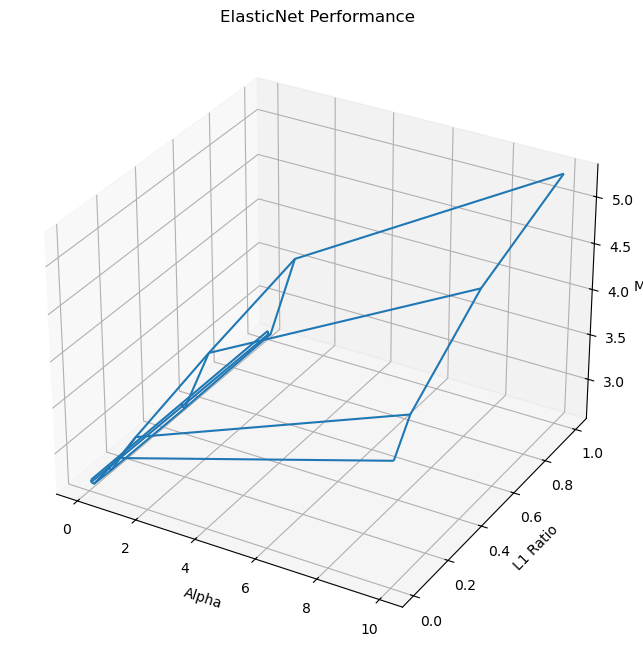

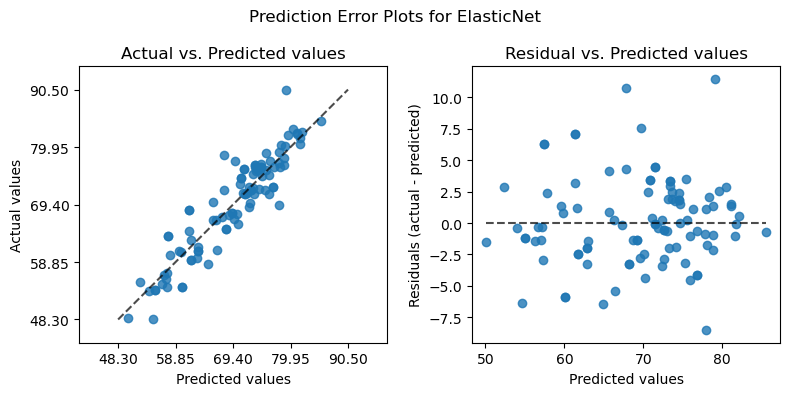

Training SVR polynomial regression...
Results: [(0.1, 0.01, 'scale', 5.215145466188459, 46.38508120564972, 0.4263243677744931), (0.1, 0.01, 'auto', 6.960542230475427, 78.42886088456135, 0.030017299027668365), (0.1, 0.01, 0.01, 7.121458160016842, 81.8662381279215, -0.01249506727691041), (0.1, 0.01, 0.1, 7.20324009427603, 83.55720518190941, -0.033408399075731454), (0.1, 0.01, 1, 7.206841125845084, 83.62895704548289, -0.03429580284067013), (0.1, 0.1, 'scale', 5.2144014093748545, 46.337792327328934, 0.4269092212761533), (0.1, 0.1, 'auto', 6.9615435488481845, 78.30196699568249, 0.03158668146779786), (0.1, 0.1, 0.01, 7.121810213038747, 81.78607261779854, -0.011503606261706434), (0.1, 0.1, 0.1, 7.203810191235999, 83.48747547706346, -0.03254600471373714), (0.1, 0.1, 1, 7.207561663431533, 83.54000648978293, -0.03319569123254862), (0.1, 0.2, 'scale', 5.214911498399566, 46.357610301412834, 0.4266641190036875), (0.1, 0.2, 'auto', 6.962282324065257, 78.25719804422157, 0.03214036933178066), (0.1, 0.

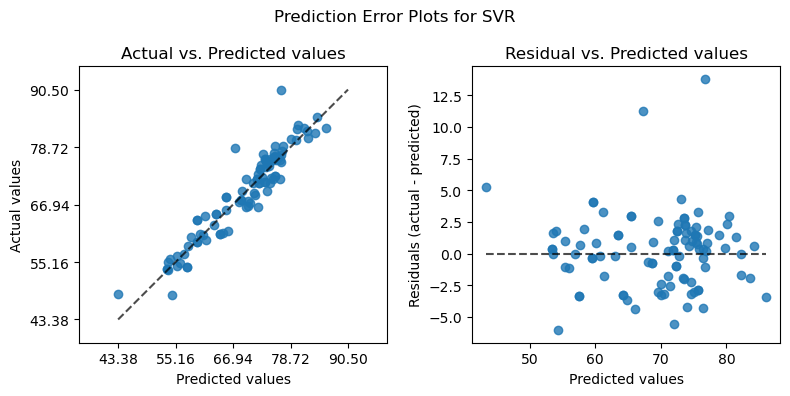

In [49]:
for name, info in regularized_models.items():
    print(f"Training {name} polynomial regression...")
    
    pipeline_steps = [
        ("scaler", scaler),
        ("transformer", transformer),
        ("poly", poly),
    ]
    train_and_plot_regularized_model(name, info, X_train, y_train, X_valid, y_valid, pipeline_steps)

### **Non-linear models with Hyperparameter tuning**

Training RandomForest model with Hyperparameter Tuning...


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for RandomForest model with Hyperparameter Tuning: {'model__bootstrap': True, 'model__criterion': 'squared_error', 'model__max_depth': 11, 'model__max_features': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 9, 'model__n_estimators': 251, 'model__warm_start': True}
RandomForest model with Hyperparameter Tuning MAE: 2.0854, MSE: 7.4333, R²: 0.9081


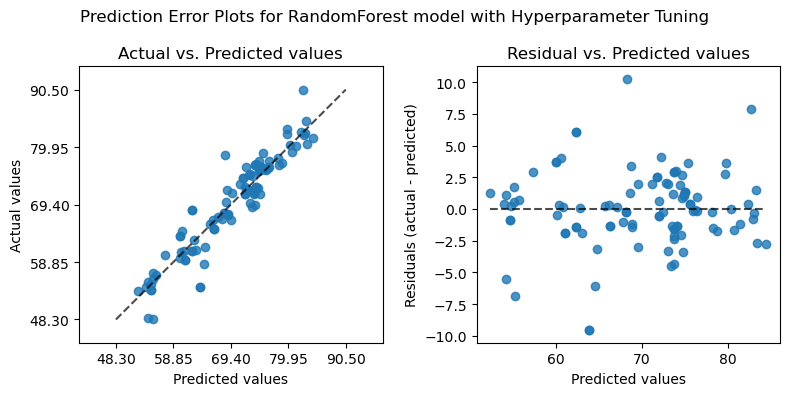

Training GradientBoosting model with Hyperparameter Tuning...


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for GradientBoosting model with Hyperparameter Tuning: {'model__learning_rate': 0.01, 'model__loss': 'absolute_error', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 18, 'model__min_samples_split': 13, 'model__n_estimators': 1161, 'model__subsample': 0.8}
GradientBoosting model with Hyperparameter Tuning MAE: 2.0675, MSE: 6.9930, R²: 0.9135


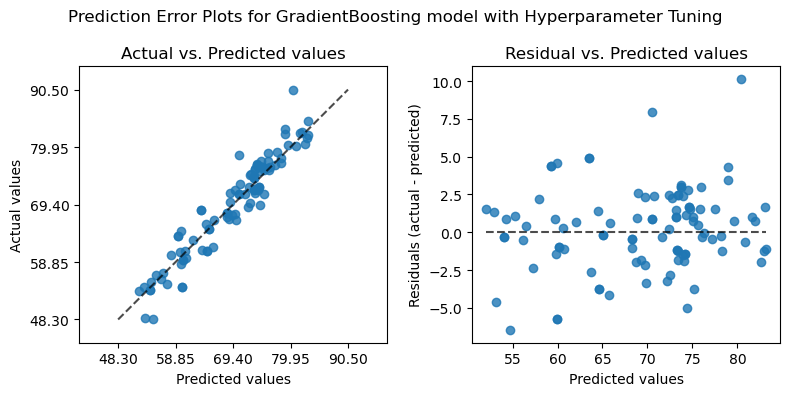

Training HistGradientBoosting model with Hyperparameter Tuning...
Best parameters for HistGradientBoosting model with Hyperparameter Tuning: {'model__categorical_features': None, 'model__l2_regularization': 0.1, 'model__learning_rate': 0.01, 'model__max_bins': 64, 'model__max_depth': 8, 'model__max_iter': 289, 'model__min_samples_leaf': 8, 'model__tol': 0.0001, 'model__validation_fraction': 0.1}
HistGradientBoosting model with Hyperparameter Tuning MAE: 2.1316, MSE: 7.6208, R²: 0.9057


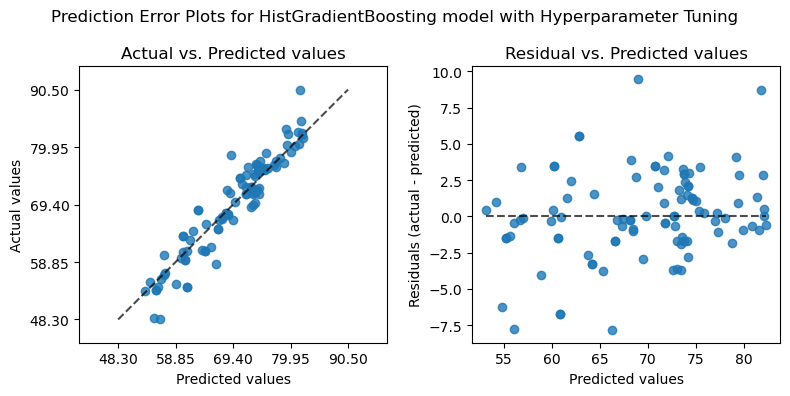

Training DecisionTree model with Hyperparameter Tuning...
Best parameters for DecisionTree model with Hyperparameter Tuning: {'model__max_depth': 12, 'model__max_features': None, 'model__max_leaf_nodes': None, 'model__min_samples_leaf': 10, 'model__min_samples_split': 17, 'model__random_state': 42, 'model__splitter': 'best'}
DecisionTree model with Hyperparameter Tuning MAE: 2.5967, MSE: 11.4246, R²: 0.8587


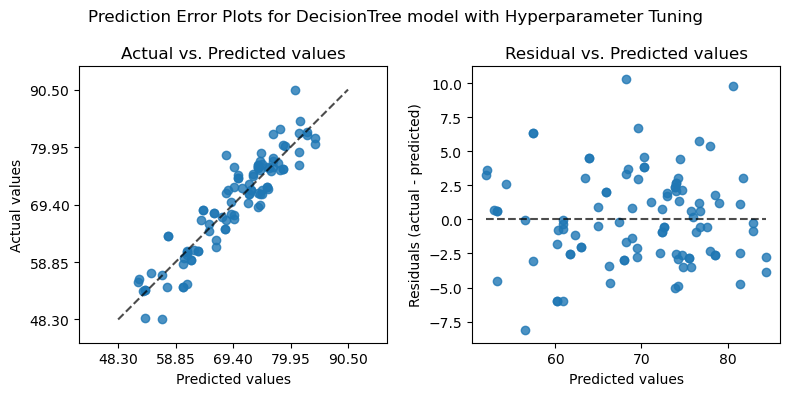

Training ExtraTrees model with Hyperparameter Tuning...
Best parameters for ExtraTrees model with Hyperparameter Tuning: {'model__bootstrap': True, 'model__max_depth': 12, 'model__max_features': None, 'model__min_samples_leaf': 8, 'model__min_samples_split': 16, 'model__n_estimators': 534}
ExtraTrees model with Hyperparameter Tuning MAE: 2.2258, MSE: 8.1968, R²: 0.8986


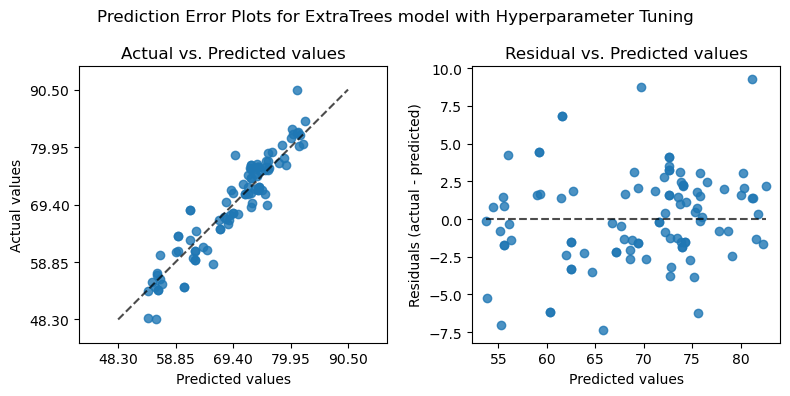

Training KNN model with Hyperparameter Tuning...
Best parameters for KNN model with Hyperparameter Tuning: {'model__p': 1, 'model__n_neighbors': 3, 'model__algorithm': 'ball_tree'}
KNN model with Hyperparameter Tuning MAE: 2.2666, MSE: 8.6791, R²: 0.8927


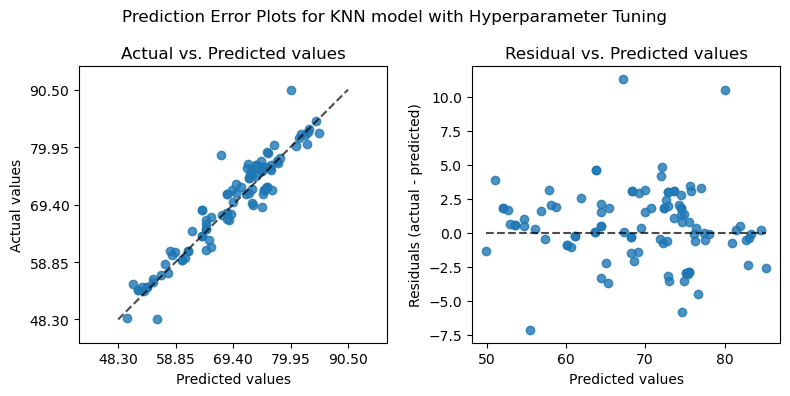

Training AdaBoost model with Hyperparameter Tuning...


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for AdaBoost model with Hyperparameter Tuning: {'model__learning_rate': 0.7419939418114051, 'model__loss': 'linear', 'model__n_estimators': 70, 'model__random_state': 42}
AdaBoost model with Hyperparameter Tuning MAE: 2.7380, MSE: 11.5040, R²: 0.8577


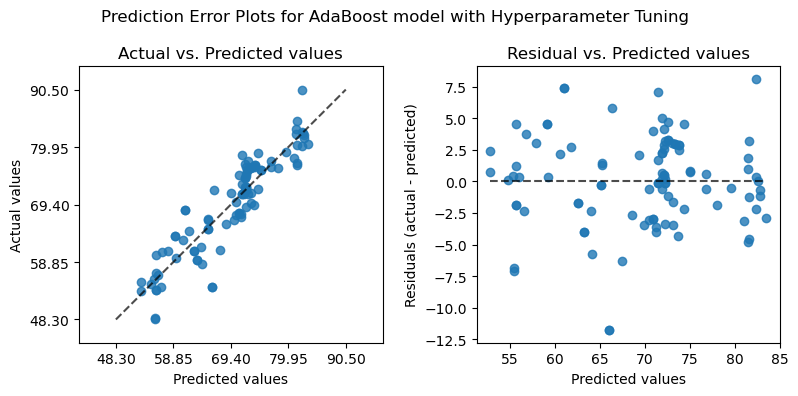

Training XGBoost model with Hyperparameter Tuning...
Best parameters for XGBoost model with Hyperparameter Tuning: {'model__colsample_bytree': 1.0, 'model__gamma': 0.0979914312095726, 'model__learning_rate': 0.04356818667316142, 'model__max_depth': 10, 'model__min_child_weight': 10, 'model__n_estimators': 117, 'model__reg_alpha': 0.2698460661945399, 'model__subsample': 0.6}
XGBoost model with Hyperparameter Tuning MAE: 2.0835, MSE: 7.1219, R²: 0.9119


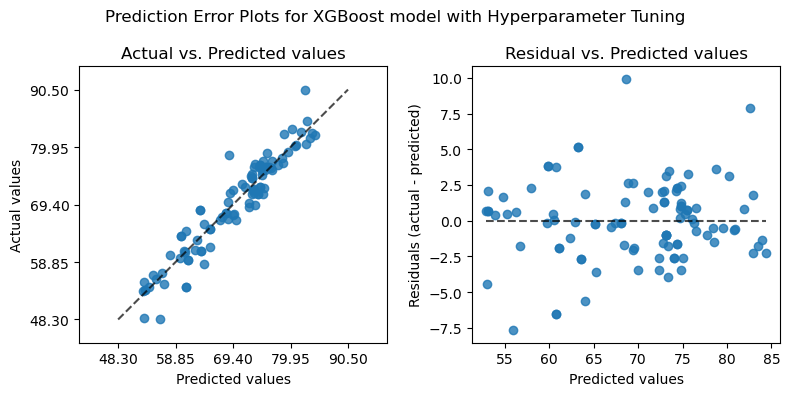

In [50]:
for name, info in models.items():
    model_name = f"{name} model with Hyperparameter Tuning"
    print(f"Training {model_name}...")
    pipeline_steps = [
        ("scaler", scaler),
        ("transformer", transformer)
    ]
    train_and_plot_model(
        name=model_name,
        info=info, 
        tuning=True, 
        X_train=X_train, 
        y_train=y_train, 
        X_valid=X_valid,
        y_valid=y_valid,
        pipeline=pipeline_steps
    )

### **Manual K-Fold Cross Validation for regularized models**

In [96]:
from collections import defaultdict
from itertools import product

def kfolds_cv(name, info, X_train, y_train, pipeline):
    kFold = KFold(n_splits=5, shuffle=True, random_state=42)
    base_model = info["model"]
    params = info["params"]

    # To collect metrics for each param combination
    metrics_dict = defaultdict(lambda: {'mse': [], 'mae': [], 'r2': []})

    for fold_idx, (train_idx, valid_idx) in enumerate(kFold.split(X_train, y_train)):
        trainX = X_train.iloc[train_idx].values
        trainY = y_train.iloc[train_idx].values
        validX = X_train.iloc[valid_idx].values
        validY = y_train.iloc[valid_idx].values

        if name == "SVR":
            for c, epsilon, gamma in product(params["C"], params["epsilon"], params["gamma"]):
                model = clone(base_model)
                model.set_params(C=c, epsilon=epsilon, gamma=gamma)
                full_pipeline = Pipeline(pipeline + [('model', model)])
                full_pipeline.fit(trainX, trainY.ravel())
                y_pred = full_pipeline.predict(validX)

                mse = mean_squared_error(validY, y_pred)
                mae = mean_absolute_error(validY, y_pred)
                r2 = r2_score(validY, y_pred)

                key = (c, epsilon, gamma)
                metrics_dict[key]['mse'].append(mse)
                metrics_dict[key]['mae'].append(mae)
                metrics_dict[key]['r2'].append(r2)
                # print(f"Fold {fold_idx} | Params: {key} | MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

        elif name == "ElasticNet":
            for alpha, l1_ratio in product(params["alphas"], params["l1_ratio"]):
                model = clone(base_model)
                model.set_params(alpha=alpha, l1_ratio=l1_ratio)
                full_pipeline = Pipeline(pipeline + [('model', model)])
                full_pipeline.fit(trainX, trainY)
                y_pred = full_pipeline.predict(validX)

                mse = mean_squared_error(validY, y_pred)
                mae = mean_absolute_error(validY, y_pred)
                r2 = r2_score(validY, y_pred)

                key = (alpha, l1_ratio)
                metrics_dict[key]['mse'].append(mse)
                metrics_dict[key]['mae'].append(mae)
                metrics_dict[key]['r2'].append(r2)
                
                # print(f"Fold {fold_idx} | Params: {key} | MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

        else:  # Ridge, Lasso
            for alpha in params["alphas"]:
                model = clone(base_model)
                model.set_params(alpha=alpha)
                full_pipeline = Pipeline(pipeline + [('model', model)])
                full_pipeline.fit(trainX, trainY)
                y_pred = full_pipeline.predict(validX)

                mse = mean_squared_error(validY, y_pred)
                mae = mean_absolute_error(validY, y_pred)
                r2 = r2_score(validY, y_pred)

                key = (alpha,)
                metrics_dict[key]['mse'].append(mse)
                metrics_dict[key]['mae'].append(mae)
                metrics_dict[key]['r2'].append(r2)
                
                # print(f"Fold {fold_idx} | Params: {key} | MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    # Compute average metrics
    avg_metrics = {}
    for params, scores in metrics_dict.items():
        avg_mse = np.mean(scores['mse'])
        avg_mae = np.mean(scores['mae'])
        avg_r2 = np.mean(scores['r2'])
        avg_metrics[params] = (avg_mse, avg_mae, avg_r2)

    # Find best based on lowest avg MAE
    best_params = min(avg_metrics.items(), key=lambda x: x[1][1])  

    print("\n=== Best Parameters ===")
    print(f"Params: {best_params[0]}")
    print(f"Average MSE: {best_params[1][0]:.4f}")
    print(f"Average MAE: {best_params[1][1]:.4f}")
    print(f"Average R² : {best_params[1][2]:.4f}")


In [97]:
for name, info in regularized_models.items():
    print("---------------------------------------------------")
    print(f"Traing {name} with 5-fold cross validation...")
    pipeline_steps = [
        ("scaler", scaler),
        ("transformer", transformer),  
    ]
    kfolds_cv(
        name=name, 
        info=info, 
        X_train=X_train, 
        y_train=y_train, 
        pipeline=pipeline_steps)

---------------------------------------------------
Traing Lasso with 5-fold cross validation...

=== Best Parameters ===
Params: (0.01,)
Average MSE: 27.0354
Average MAE: 4.0095
Average R² : 0.7069
---------------------------------------------------
Traing Ridge with 5-fold cross validation...

=== Best Parameters ===
Params: (1e-05,)
Average MSE: 27.0649
Average MAE: 4.0108
Average R² : 0.7066
---------------------------------------------------
Traing ElasticNet with 5-fold cross validation...

=== Best Parameters ===
Params: (0.01, 1)
Average MSE: 27.0354
Average MAE: 4.0095
Average R² : 0.7069
---------------------------------------------------
Traing SVR with 5-fold cross validation...

=== Best Parameters ===
Params: (100, 0.5, 0.01)
Average MSE: 13.2409
Average MAE: 2.7255
Average R² : 0.8561


In [98]:
for name, info in regularized_models.items():
    print("---------------------------------------------------")
    print(f"Traing {name} polynomial regression with 5-fold cross validation...")
    pipeline_steps = [
        ("scaler", scaler),
        ("transformer", transformer),
        ("poly", poly)
    ]
    kfolds_cv(
        name=name, 
        info=info, 
        X_train=X_train, 
        y_train=y_train, 
        pipeline=pipeline_steps)

---------------------------------------------------
Traing Lasso polynomial regression with 5-fold cross validation...

=== Best Parameters ===
Params: (0.1,)
Average MSE: 14.8436
Average MAE: 2.8840
Average R² : 0.8390
---------------------------------------------------
Traing Ridge polynomial regression with 5-fold cross validation...

=== Best Parameters ===
Params: (1,)
Average MSE: 15.5234
Average MAE: 2.9281
Average R² : 0.8311
---------------------------------------------------
Traing ElasticNet polynomial regression with 5-fold cross validation...

=== Best Parameters ===
Params: (0.1, 0.5)
Average MSE: 14.8548
Average MAE: 2.8796
Average R² : 0.8388
---------------------------------------------------
Traing SVR polynomial regression with 5-fold cross validation...

=== Best Parameters ===
Params: (100, 0.5, 'scale')
Average MSE: 14.5219
Average MAE: 2.8597
Average R² : 0.8423


### **Ensembles**

VotingRegressor MAE: 1.9932, MSE: 6.5255, R²: 0.9193


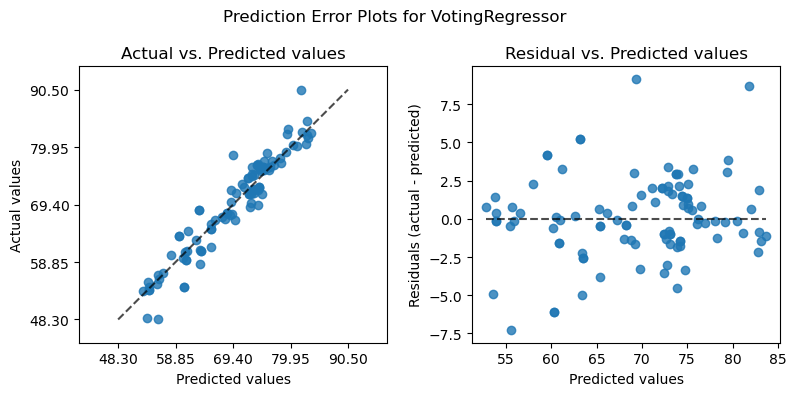

In [58]:
voting_pipeline = Pipeline([
    ("scaler", scaler),
    ("transformer", transformer),
    ("ensemble", VotingRegressor([
        ("rf", RandomForestRegressor()),
        ("gbr", GradientBoostingRegressor(**{k.replace("model__", ""): v for k, v in best_params_dict["GradientBoosting model with Hyperparameter Tuning"].items()})),
        ("hgbr", HistGradientBoostingRegressor(**{k.replace("model__", ""): v for k, v in best_params_dict["HistGradientBoosting model with Hyperparameter Tuning"].items()})),
        ('et', ExtraTreesRegressor()),
        ("xgb", xgb.XGBRegressor(**{k.replace("model__", ""): v for k, v in best_params_dict["XGBoost model with Hyperparameter Tuning"].items()}))
    ]))
])

# Fit and predict
voting_pipeline.fit(X_train, y_train.values.ravel())
voting_pred = voting_pipeline.predict(X_valid)

mse = mean_squared_error(y_valid, voting_pred)
mae = mean_absolute_error(y_valid, voting_pred)
r2 = r2_score(y_valid, voting_pred)

print(f"VotingRegressor MAE: {mae:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

plot_cross_validated_pred(voting_pred, y_valid, "VotingRegressor")


StackingRegressor MAE: 1.9393, MSE: 6.1052, R²: 0.9245


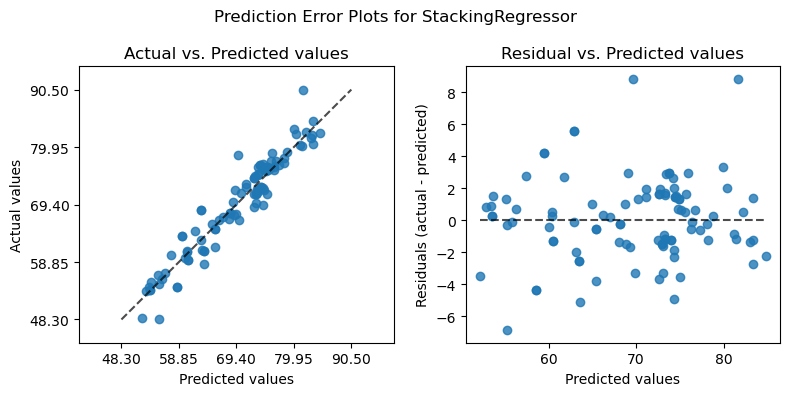

In [56]:
stacking_pipeline = Pipeline([
    ("scaler", scaler),
    ("transformer", transformer),
    ("ensemble", StackingRegressor(
        estimators=[
            ("rf", RandomForestRegressor()),
            ("gbr", GradientBoostingRegressor(**{k.replace("model__", ""): v for k, v in best_params_dict["GradientBoosting model with Hyperparameter Tuning"].items()})),
            ("hgbr", HistGradientBoostingRegressor(**{k.replace("model__", ""): v for k, v in best_params_dict["HistGradientBoosting model with Hyperparameter Tuning"].items()})),
            ('et', ExtraTreesRegressor()),
            ("xgb", xgb.XGBRegressor(**{k.replace("model__", ""): v for k, v in best_params_dict["XGBoost model with Hyperparameter Tuning"].items()}))
        ],
        final_estimator=RidgeCV()
    ))
])

stacking_pipeline.fit(X_train, y_train.values.ravel())
stacking_pred = stacking_pipeline.predict(X_valid)

mse = mean_squared_error(y_valid, stacking_pred)
mae = mean_absolute_error(y_valid, stacking_pred)
r2 = r2_score(y_valid, stacking_pred)

print(f"StackingRegressor MAE: {mae:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")
plot_cross_validated_pred(stacking_pred, y_valid, "StackingRegressor")

## **Predicting on test set**

In [74]:
test_pred = stacking_pipeline.predict(test)
submission = pd.read_csv("COSC2753_A1_Predictions_s3978387.csv")
submission["TARGET_LifeExpectancy"] = test_pred
submission.to_csv("COSC2753_A1_Predictions_s3978387.csv", index=False)